In [1]:
import pandas as pd
import numpy as np

# Load review and survey data
survey_df = pd.read_csv('data/Survey_Data_Output [DW].csv')      # 28 columns: 4 determinants + demographics
reviews_df = pd.read_csv('data/output_data/english/version_2/classified_reviews_comprehensive.csv')    # Annotated, with 'missing' indicator

# Quick summary
print(survey_df.info())
print(reviews_df.info())

# Check for missing data
print(reviews_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402 entries, 0 to 401
Data columns (total 41 columns):
 #   Column                                                                                                 Non-Null Count  Dtype 
---  ------                                                                                                 --------------  ----- 
 0   Timestamp                                                                                              402 non-null    object
 1   Column 1                                                                                               402 non-null    object
 2   Age                                                                                                    402 non-null    object
 3   Gender                                                                                                 402 non-null    object
 4   Educational attainment                                                                                 4

In [2]:
import matplotlib.pyplot as plt
from pyfonts import load_google_font, set_default_font

font = load_google_font("IBM Plex Sans", weight='regular', italic=False)
bold_font = load_google_font("IBM Plex Sans", weight='bold', italic=False)

set_default_font(font)
plt.rcParams['figure.dpi'] = 300

## Survey Data

In [3]:
survey_df_copy = survey_df.copy()
survey_df_copy.columns

Index(['Timestamp', 'Column 1', 'Age', 'Gender', 'Educational attainment',
       'Employment', 'Income level (monthly)', 'Do you have a bank account?',
       '​​Does your bank offer facilities on mobile banking?​ ',
       'Do you use mobile banking?', 'Frequency of using mobile banking',
       'How long have you been using mobile banking services?',
       'Which bank do you use most frequently for mobile banking transactions?',
       '​​The mobile banking app allows me to easily access and manage my​ account at any time. ',
       '​​The mobile banking app works efficiently across multiple devices (e.g., smartphone,​ ​tablet).​ ',
       '​​The loading speed of the mobile banking app is fast and reliable.​',
       '​​The mobile banking app’s interface is user-friendly and intuitive to navigate​. ',
       '​​I can easily access essential services, such as transfers and bill payments, within the​ app. ',
       '​​The app has minimal errors and disruptions when I perform banking 

In [4]:
rating_map = {
    '1 - Strongly disagree': 1,
    '2 - Disagree': 2,
    '3 - Neither agree nor disagree': 3,
    '4 - Agree': 4,
    '5 - Strongly agree': 5
}

for col in survey_df_copy.columns:
    # List of non-rating columns to exclude
    if col not in ['Timestamp', 'Column 1', 'Age', 'Gender', 'Educational attainment',
                   'Employment', 'Income level (monthly)', 'Do you have a bank account?',
                   '​​Does your bank offer facilities on mobile banking?​ ',
                   'Do you use mobile banking?', 'Frequency of using mobile banking', 'How long have you been using mobile banking services?',
       'Which bank do you use most frequently for mobile banking transactions?']:
        survey_df_copy[col] = survey_df_copy[col].map(rating_map)

In [5]:
# Remove leading/trailing whitespace and hidden unicode from column names
survey_df_copy.columns = survey_df_copy.columns.str.strip().str.replace('\u200b', '').str.replace('\u200c', '')

In [6]:
print((survey_df_copy.columns))

Index(['Timestamp', 'Column 1', 'Age', 'Gender', 'Educational attainment',
       'Employment', 'Income level (monthly)', 'Do you have a bank account?',
       'Does your bank offer facilities on mobile banking?',
       'Do you use mobile banking?', 'Frequency of using mobile banking',
       'How long have you been using mobile banking services?',
       'Which bank do you use most frequently for mobile banking transactions?',
       'The mobile banking app allows me to easily access and manage my account at any time.',
       'The mobile banking app works efficiently across multiple devices (e.g., smartphone, tablet).',
       'The loading speed of the mobile banking app is fast and reliable.',
       'The mobile banking app’s interface is user-friendly and intuitive to navigate.',
       'I can easily access essential services, such as transfers and bill payments, within the app.',
       'The app has minimal errors and disruptions when I perform banking tasks.',
       'The design

In [7]:
# Example: Suppose each determinant has 7 survey items, grouped by prefix
determinant_groups = {
    'accessibility': ['The mobile banking app allows me to easily access and manage my account at any time.',
       'The mobile banking app works efficiently across multiple devices (e.g., smartphone, tablet).',
       'The loading speed of the mobile banking app is fast and reliable.',
       'The mobile banking app’s interface is user-friendly and intuitive to navigate.',
       'I can easily access essential services, such as transfers and bill payments, within the app.',
       'The app has minimal errors and disruptions when I perform banking tasks.',
       'The design of the mobile banking app allows me to complete tasks efficiently.'],  # fill in actual survey column names
    'security': ['The mobile banking app ensures secure login and authentication for each session.',
       'I feel confident that my personal information is protected by the app’s strong encryption methods.',
       'The app provides advanced security features, such as two-factor authentication (2FA).',
       'I trust the app’s security features and monitoring systems to safeguard my financial information.',
       'The app actively monitors for suspicious activity and prevents unauthorized access.',
       'I can easily adjust and control the app\'s security settings to suit my preferences.',
       'The app’s fraud detection mechanisms make me feel secure while conducting transactions.'],
    'convenience': ['The mobile banking app allows me to perform transactions efficiently and in a timely manner.',
       'I can access the mobile banking app anytime, day or night.',
       'I can easily integrate the app with other financial services such as bill payments and transfers.',
       'The app offers personalized features that enhance my banking experience beyond basic tasks.',
       'I receive useful updates and notifications regarding my account.',
       'I can use the mobile banking app reliably even in areas with slow internet connectivity.',
       'The app’s features save me time compared to in-person banking services.'],
    'customer_support': ['The mobile banking app provides prompt notifications regarding my transactions.',
       'The app offers multiple support channels (e.g., chat, email, phone) to resolve issues.',
       'Customer support through the app responds promptly and resolves concerns effectively.',
       'I find the support staff to be knowledgeable and helpful in resolving issues.',
       'The mobile banking app provides timely responses to my queries and concerns.',
       'I feel supported by the app’s customer service when I experience issues.',
       'The app allows me to easily track the status of my support requests.'],
}
mcda_weights = {}

# Calculate the mean/aggregate score for each determinant for each respondent
for det, columns in determinant_groups.items():
    survey_df_copy[f'{det}_score'] = survey_df_copy[columns].mean(axis=1)

# Compute AHP/MCDA weights as normalized mean scores (replace with AHP if you have the actual scoring)
det_means = {det: survey_df_copy[f'{det}_score'].mean() for det in determinant_groups}
total = sum(det_means.values())
for det in det_means:
    mcda_weights[det] = det_means[det] / total
print("MCDA/AHP Weights:", mcda_weights)


MCDA/AHP Weights: {'accessibility': np.float64(0.25781384535904944), 'security': np.float64(0.25594110556225247), 'convenience': np.float64(0.25424057172378167), 'customer_support': np.float64(0.23200447735491653)}


## Review Data

In [8]:
df = reviews_df.copy()
print(df.columns)

Index(['processed_review', 'topic_classification', 'classification_status',
       'score', 'bank'],
      dtype='object')


In [9]:
df = df[df['topic_classification'] != '{\n  "topics": [],\n  "ratings": {}\n}']
print(f"✅ Filtered out empty classifications")
print(f"   Remaining rows: {len(df):,}")

✅ Filtered out empty classifications
   Remaining rows: 42,199


In [10]:
# Let's first examine a sample of the topic classifications to understand the format
print("📊 Sample Topic Classifications:")
sample_topics = df['topic_classification'].dropna().head(10)
for i, topic in enumerate(sample_topics):
    print(f"{i+1}: {topic}")
    
print(f"\n📈 Total non-null classifications: {df['topic_classification'].notna().sum()}")
print(f"📈 Total null classifications: {df['topic_classification'].isna().sum()}")

📊 Sample Topic Classifications:
1: {
  "topics": ["Convenience"],
  "ratings": {
    "Convenience": 1
  }
}
2: {
  "topics": ["Convenience", "Customer Support"],
  "ratings": {
    "Convenience": 1,
    "Customer Support": 1
  }
}
3: {
  "topics": ["Convenience", "Security"],
  "ratings": {
    "Convenience": 1,
    "Security": 3
  }
}
4: {
  "topics": ["Convenience"],
  "ratings": {
    "Convenience": 1
  }
}
5: {
  "topics": ["Accessibility"],
  "ratings": {
    "Accessibility": 1
  }
}
6: {
  "topics": ["Convenience"],
  "ratings": {
    "Convenience": 1
  }
}
7: {
  "topics": ["Convenience"],
  "ratings": {
    "Convenience": 1
  }
}
8: {
  "topics": ["Security", "Convenience"],
  "ratings": {
    "Security": 1,
    "Convenience": 1
  }
}
9: {
  "topics": ["Convenience", "Security"],
  "ratings": {
    "Convenience": 1,
    "Security": 1
  }
}
10: {
  "topics": ["Convenience"],
  "ratings": {
    "Convenience": 1
  }
}

📈 Total non-null classifications: 42199
📈 Total null classific

In [11]:
import json
import re

def clean_and_parse_topic_classification(text):
    """
    Clean and parse topic classification text into structured format
    """
    if pd.isna(text) or text is None:
        return None, None
    
    # Convert to string and clean
    text = str(text).strip()
    
    # Remove markdown code block formatting if present
    text = re.sub(r'^```json\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    
    # Try to parse as JSON
    try:
        parsed = json.loads(text)
        
        # Handle case where parsed is a list instead of dict
        if isinstance(parsed, list):
            return None, None
        
        # Handle case where parsed is a dict
        if isinstance(parsed, dict):
            topics = parsed.get('topics', [])
            ratings = parsed.get('ratings', {})
            return topics, ratings
        
        # Unexpected type
        return None, None
        
    except json.JSONDecodeError:
        # If JSON parsing fails, try to extract topics manually
        try:
            # Look for patterns like "topics": ["topic1", "topic2"]
            topics_match = re.search(r'"topics":\s*\[(.*?)\]', text)
            if topics_match:
                topics_str = topics_match.group(1)
                topics = [t.strip().strip('"') for t in topics_str.split(',') if t.strip()]
                return topics, {}
            else:
                return None, None
        except:
            return None, None

# Test the function on a few samples
print("🧪 Testing parsing function:")
test_samples = df['topic_classification'].dropna().head(5)
for i, sample in enumerate(test_samples):
    topics, ratings = clean_and_parse_topic_classification(sample)
    print(f"{i+1}: Topics: {topics}, Ratings: {ratings}")

🧪 Testing parsing function:
1: Topics: ['Convenience'], Ratings: {'Convenience': 1}
2: Topics: ['Convenience', 'Customer Support'], Ratings: {'Convenience': 1, 'Customer Support': 1}
3: Topics: ['Convenience', 'Security'], Ratings: {'Convenience': 1, 'Security': 3}
4: Topics: ['Convenience'], Ratings: {'Convenience': 1}
5: Topics: ['Accessibility'], Ratings: {'Accessibility': 1}


In [12]:
def preprocess_topic_classifications(df):
    """
    Preprocess topic classifications into separate columns for ML
    
    Creates:
    - Binary columns for each topic (1 if present, 0 if not)
    - Rating columns for each topic (actual rating if present, NaN if not)
    - Missing indicator columns (1 if missing, 0 if present)
    """
    
    print("🔄 Preprocessing topic classifications...")
    
    # Define the expected topics
    topics = ['Accessibility', 'Security', 'Convenience', 'Customer Support']
    
    # Create a copy of the dataframe
    df_processed = df.copy()
    
    # Initialize columns with proper dtypes
    for topic in topics:
        topic_clean = topic.lower().replace(' ', '_')
        df_processed[f'{topic_clean}_present'] = 0  # Binary: topic present
        df_processed[f'{topic_clean}_rating'] = np.nan  # Rating if present
        df_processed[f'{topic_clean}_missing'] = 1  # Missing indicator
    
    # Convert rating columns to float
    for topic in topics:
        topic_clean = topic.lower().replace(' ', '_')
        df_processed[f'{topic_clean}_rating'] = df_processed[f'{topic_clean}_rating'].astype('float64')
    
    # Parse each classification
    parsing_errors = 0
    successful_parses = 0
    
    for idx, row in df_processed.iterrows():
        classification_text = row['topic_classification']
        
        # Parse the classification
        parsed_topics, parsed_ratings = clean_and_parse_topic_classification(classification_text)
        
        if parsed_topics is not None:
            successful_parses += 1
            
            # Reset all topics to not present for this row
            for topic in topics:
                topic_clean = topic.lower().replace(' ', '_')
                df_processed.loc[idx, f'{topic_clean}_present'] = 0
                df_processed.loc[idx, f'{topic_clean}_rating'] = np.nan
                df_processed.loc[idx, f'{topic_clean}_missing'] = 1
            
            # Set present topics
            for topic in parsed_topics:
                if topic in topics:
                    topic_clean = topic.lower().replace(' ', '_')
                    df_processed.loc[idx, f'{topic_clean}_present'] = 1
                    df_processed.loc[idx, f'{topic_clean}_missing'] = 0
                    
                    # Set rating if available - ensure it's numeric
                    if parsed_ratings and topic in parsed_ratings:
                        try:
                            rating_value = float(parsed_ratings[topic])
                            df_processed.loc[idx, f'{topic_clean}_rating'] = rating_value
                        except (ValueError, TypeError):
                            # If rating can't be converted to float, skip it
                            pass
        else:
            parsing_errors += 1
    
    print(f"✅ Preprocessing completed:")
    print(f"   Successfully parsed: {successful_parses:,}")
    print(f"   Parsing errors: {parsing_errors:,}")
    print(f"   Total rows: {len(df_processed):,}")
    
    # Show summary statistics
    print(f"\n📊 Topic Presence Summary:")
    for topic in topics:
        topic_clean = topic.lower().replace(' ', '_')
        present_count = df_processed[f'{topic_clean}_present'].sum()
        present_pct = (present_count / len(df_processed)) * 100
        print(f"   {topic}: {present_count:,} ({present_pct:.1f}%)")
    
    # Show rating statistics
    print(f"\n⭐ Rating Statistics:")
    for topic in topics:
        topic_clean = topic.lower().replace(' ', '_')
        ratings = df_processed[f'{topic_clean}_rating'].dropna()
        if len(ratings) > 0:
            print(f"   {topic}: avg={ratings.mean():.2f}, count={len(ratings):,}, range={ratings.min()}-{ratings.max()}")
        else:
            print(f"   {topic}: No ratings available")
    
    return df_processed

# Apply preprocessing
df_with_topics = preprocess_topic_classifications(df)

🔄 Preprocessing topic classifications...


✅ Preprocessing completed:
   Successfully parsed: 42,199
   Parsing errors: 0
   Total rows: 42,199

📊 Topic Presence Summary:
   Accessibility: 8,629 (20.4%)
   Security: 15,676 (37.1%)
   Convenience: 35,698 (84.6%)
   Customer Support: 13,059 (30.9%)

⭐ Rating Statistics:
   Accessibility: avg=1.22, count=8,629, range=1.0-5.0
   Security: avg=1.70, count=15,676, range=1.0-5.0
   Convenience: avg=1.49, count=35,698, range=1.0-5.0
   Customer Support: avg=1.27, count=13,051, range=1.0-5.0


In [13]:
# Show the new structure of the processed data
print("📋 NEW COLUMNS CREATED:")
new_columns = [col for col in df_with_topics.columns if col not in df.columns]
for col in new_columns:
    print(f"   • {col}")

print(f"\n📊 SAMPLE OF PROCESSED DATA:")
# Show a few rows with the new topic columns
topic_columns = [col for col in df_with_topics.columns if any(topic.lower().replace(' ', '_') in col for topic in ['accessibility', 'security', 'convenience', 'customer_support'])]
sample_columns = ['bank', 'score'] + topic_columns[:8]  # Show first 8 topic columns
print(df_with_topics[sample_columns].head())

print(f"\n📈 DATA SUMMARY:")
print(f"   Original columns: {len(df.columns)}")
print(f"   New columns: {len(new_columns)}")
print(f"   Total columns: {len(df_with_topics.columns)}")

# Create a clean ML-ready dataset
print(f"\n🎯 CREATING ML-READY DATASET:")

# Select relevant columns for ML
ml_columns = ['bank', 'score']

# Add all the new topic-related columns
for topic in ['accessibility', 'security', 'convenience', 'customer_support']:
    ml_columns.extend([
        f'{topic}_present',
        f'{topic}_rating', 
        f'{topic}_missing'
    ])

df_ml_ready = df_with_topics[ml_columns].copy()

print(f"✅ ML-ready dataset created with {len(ml_columns)} columns:")
for col in ml_columns:
    print(f"   • {col}")

# Check for any remaining data quality issues
print(f"\n🔍 DATA QUALITY CHECK:")
print(f"   Rows: {len(df_ml_ready):,}")
print(f"   Missing values per column:")
for col in df_ml_ready.columns:
    missing_count = df_ml_ready[col].isna().sum()
    missing_pct = (missing_count / len(df_ml_ready)) * 100
    if missing_count > 0:
        print(f"     {col}: {missing_count:,} ({missing_pct:.1f}%)")

print(f"\n🎉 Topic classification preprocessing completed!")
print(f"📁 Use 'df_ml_ready' for machine learning tasks")

📋 NEW COLUMNS CREATED:
   • accessibility_present
   • accessibility_rating
   • accessibility_missing
   • security_present
   • security_rating
   • security_missing
   • convenience_present
   • convenience_rating
   • convenience_missing
   • customer_support_present
   • customer_support_rating
   • customer_support_missing

📊 SAMPLE OF PROCESSED DATA:
  bank  score  accessibility_present  accessibility_rating  \
0  BDO      1                      0                   NaN   
1  BDO      2                      0                   NaN   
2  BDO      3                      0                   NaN   
3  BDO      1                      0                   NaN   
4  BDO      2                      1                   1.0   

   accessibility_missing  security_present  security_rating  security_missing  \
0                      1                 0              NaN                 1   
1                      1                 0              NaN                 1   
2                      1

In [14]:
# Find rows where ratings are negative numbers
print("🔍 ANALYSIS OF NEGATIVE RATINGS")
print("=" * 50)

# Define rating columns
rating_columns = ['accessibility_rating', 'security_rating', 'convenience_rating', 'customer_support_rating']

# Find negative ratings for each column
negative_stats = {}
all_negative_rows = pd.DataFrame()

for col in rating_columns:
    # Find rows with negative ratings (excluding NaN)
    negative_mask = (df_ml_ready[col] < 0) & (df_ml_ready[col].notna())
    negative_rows = df_ml_ready[negative_mask]
    
    if len(negative_rows) > 0:
        negative_stats[col] = {
            'count': len(negative_rows),
            'percentage': (len(negative_rows) / df_ml_ready[col].notna().sum()) * 100,
            'values': negative_rows[col].value_counts().sort_index(),
            'banks': negative_rows['bank'].value_counts()
        }
        
        # Add to combined negative rows
        if len(all_negative_rows) == 0:
            all_negative_rows = negative_rows.copy()
        else:
            all_negative_rows = pd.concat([all_negative_rows, negative_rows]).drop_duplicates()
    
    print(f"\n📊 {col.replace('_', ' ').title()}:")
    if len(negative_rows) > 0:
        print(f"   Negative ratings found: {len(negative_rows):,}")
        print(f"   Percentage of total ratings: {(len(negative_rows) / df_ml_ready[col].notna().sum()) * 100:.2f}%")
        print(f"   Negative values: {sorted(negative_rows[col].unique())}")
        print(f"   Banks with negative ratings: {list(negative_rows['bank'].unique())}")
    else:
        print(f"   No negative ratings found")

# Summary of all negative ratings
print(f"\n🎯 OVERALL NEGATIVE RATINGS SUMMARY:")
print(f"   Unique rows with any negative rating: {len(all_negative_rows):,}")
print(f"   Percentage of total dataset: {(len(all_negative_rows) / len(df_ml_ready)) * 100:.2f}%")

if len(all_negative_rows) > 0:
    print(f"\n📋 SAMPLE OF ROWS WITH NEGATIVE RATINGS:")
    # Show first 10 rows with negative ratings
    sample_cols = ['bank', 'score'] + rating_columns
    print(all_negative_rows[sample_cols].head(10).to_string(index=False))
    
    # Detailed analysis by rating value
    print(f"\n📈 NEGATIVE RATING VALUE ANALYSIS:")
    for col in rating_columns:
        if col in negative_stats:
            print(f"\n{col.replace('_', ' ').title()}:")
            for value, count in negative_stats[col]['values'].items():
                pct = (count / negative_stats[col]['count']) * 100
                print(f"   Rating {value}: {count:,} occurrences ({pct:.1f}%)")
    
    # Bank distribution of negative ratings
    print(f"\n🏦 NEGATIVE RATINGS BY BANK:")
    bank_negative_summary = {}
    for bank in df_ml_ready['bank'].unique():
        bank_data = all_negative_rows[all_negative_rows['bank'] == bank]
        if len(bank_data) > 0:
            total_bank_reviews = len(df_ml_ready[df_ml_ready['bank'] == bank])
            bank_negative_summary[bank] = {
                'negative_count': len(bank_data),
                'total_reviews': total_bank_reviews,
                'percentage': (len(bank_data) / total_bank_reviews) * 100
            }
    
    # Sort by percentage
    sorted_banks = sorted(bank_negative_summary.items(), key=lambda x: x[1]['percentage'], reverse=True)
    for bank, stats in sorted_banks:
        print(f"   {bank}: {stats['negative_count']:,} negative ratings / {stats['total_reviews']:,} total ({stats['percentage']:.2f}%)")

# Create a visualization of negative ratings
if len(all_negative_rows) > 0:
    print(f"\n📊 CREATING VISUALIZATION OF NEGATIVE RATINGS...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, col in enumerate(rating_columns):
        ax = axes[i]
        negative_data = df_ml_ready[df_ml_ready[col] < 0][col].dropna()
        
        if len(negative_data) > 0:
            # Create histogram of negative values
            ax.hist(negative_data, bins=np.arange(negative_data.min()-0.5, 1.5, 1), 
                   alpha=0.7, color='red', edgecolor='black')
            ax.set_title(f'Negative {col.replace("_", " ").title()} Distribution\n(n={len(negative_data)})', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Rating Value')
            ax.set_ylabel('Frequency')
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'No Negative\nRatings Found', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=14)
            ax.set_title(f'{col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.suptitle('Distribution of Negative Ratings by Topic', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

# Return the dataframe with negative ratings for further analysis
print(f"\n💡 Use 'all_negative_rows' variable to access rows with negative ratings")
all_negative_rows

🔍 ANALYSIS OF NEGATIVE RATINGS

📊 Accessibility Rating:
   No negative ratings found

📊 Security Rating:
   No negative ratings found

📊 Convenience Rating:
   No negative ratings found

📊 Customer Support Rating:
   No negative ratings found

🎯 OVERALL NEGATIVE RATINGS SUMMARY:
   Unique rows with any negative rating: 0
   Percentage of total dataset: 0.00%

💡 Use 'all_negative_rows' variable to access rows with negative ratings


""


In [15]:
# Apply preprocessing: Replace NaN with -1 (BEFORE scaling)
print("🔧 PREPROCESSING: IMPUTING MISSING VALUES AS -1")
print("=" * 60)

# Create a copy of the ML-ready dataset for preprocessing
df_preprocessed = df_ml_ready.copy()

# Define rating columns
rating_columns = ['accessibility_rating', 'security_rating', 'convenience_rating', 'customer_support_rating']

print("Before imputation:")
for col in rating_columns:
    negative_count = (df_preprocessed[col] < 0).sum()
    null_count = df_preprocessed[col].isna().sum()
    total_ratings = df_preprocessed[col].notna().sum()
    print(f"   {col}: {negative_count} negative, {null_count} null, {total_ratings} valid ratings")

print("\nApplying transformations...")

for col in rating_columns:
    # Step 1: Convert negative values to absolute values
    negative_mask = df_preprocessed[col] < 0
    if negative_mask.any():
        df_preprocessed.loc[negative_mask, col] = df_preprocessed.loc[negative_mask, col].abs()
        print(f"   {col}: Converted {negative_mask.sum()} negative values to absolute")
    
    # Step 2: Replace NaN with -1 (IMPUTATION STEP)
    null_mask = df_preprocessed[col].isna()
    if null_mask.any():
        df_preprocessed.loc[null_mask, col] = -1
        print(f"   {col}: Imputed {null_mask.sum()} NaN values as -1")

print("\nAfter imputation:")
for col in rating_columns:
    negative_count = (df_preprocessed[col] < 0).sum()
    null_count = df_preprocessed[col].isna().sum()
    missing_indicator_count = (df_preprocessed[col] == -1).sum()
    print(f"   {col}: {negative_count} values < 0 (should equal missing), {null_count} null, {missing_indicator_count} missing indicators (-1)")

# Verify no NaN values remain
assert df_preprocessed[rating_columns].isna().sum().sum() == 0, "⚠️ NaN values still present!"
print(f"\n✅ All NaN values imputed as -1")
print(f"✅ Ready for scaling (which will preserve -1 values)")

# ...existing code for visualization and summary...

# Store the preprocessed dataset
df_ml_final = df_preprocessed.copy()
print(f"\n💾 Final ML dataset stored as 'df_ml_final'")

🔧 PREPROCESSING: IMPUTING MISSING VALUES AS -1
Before imputation:
   accessibility_rating: 0 negative, 33570 null, 8629 valid ratings
   security_rating: 0 negative, 26523 null, 15676 valid ratings
   convenience_rating: 0 negative, 6501 null, 35698 valid ratings
   customer_support_rating: 0 negative, 29148 null, 13051 valid ratings

Applying transformations...
   accessibility_rating: Imputed 33570 NaN values as -1
   security_rating: Imputed 26523 NaN values as -1
   convenience_rating: Imputed 6501 NaN values as -1
   customer_support_rating: Imputed 29148 NaN values as -1

After imputation:
   accessibility_rating: 33570 values < 0 (should equal missing), 0 null, 33570 missing indicators (-1)
   security_rating: 26523 values < 0 (should equal missing), 0 null, 26523 missing indicators (-1)
   convenience_rating: 6501 values < 0 (should equal missing), 0 null, 6501 missing indicators (-1)
   customer_support_rating: 29148 values < 0 (should equal missing), 0 null, 29148 missing ind

In [16]:
df_ml_final

,bank,score,accessibility_present,accessibility_rating,accessibility_missing,security_present,security_rating,security_missing,convenience_present,convenience_rating,convenience_missing,customer_support_present,customer_support_rating,customer_support_missing
0,BDO,1,0,-1.0,1,0,-1.0,1,1,1.0,0,0,-1.0,1
1,BDO,2,0,-1.0,1,0,-1.0,1,1,1.0,0,1,1.0,0
2,BDO,3,0,-1.0,1,1,3.0,0,1,1.0,0,0,-1.0,1
3,BDO,1,0,-1.0,1,0,-1.0,1,1,1.0,0,0,-1.0,1
4,BDO,2,1,1.0,0,0,-1.0,1,0,-1.0,1,0,-1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42733,Unionbank,1,0,-1.0,1,0,-1.0,1,1,1.0,0,1,1.0,0
42735,Unionbank,1,1,1.0,0,0,-1.0,1,0,-1.0,1,1,1.0,0
42736,Unionbank,1,0,-1.0,1,1,1.0,0,1,1.0,0,0,-1.0,1
42737,Unionbank,4,1,1.0,0,1,4.0,0,0,-1.0,1,0,-1.0,1


In [17]:
for det in determinant_groups:
    # Assume the review dataset has columns like 'accessibility_rating' and -1 for missing
    df_ml_final[f'weighted_{det}'] = np.where(
        df_ml_final[f'{det}_rating'] == -1.0, -1.0, df_ml_final[f'{det}_rating'] * mcda_weights[det]
    )

## Machine Learning

In [18]:
df_ml_final

,bank,score,accessibility_present,accessibility_rating,accessibility_missing,security_present,security_rating,security_missing,convenience_present,convenience_rating,convenience_missing,customer_support_present,customer_support_rating,customer_support_missing,weighted_accessibility,weighted_security,weighted_convenience,weighted_customer_support
0,BDO,1,0,-1.0,1,0,-1.0,1,1,1.0,0,0,-1.0,1,-1.000000,-1.000000,0.254241,-1.000000
1,BDO,2,0,-1.0,1,0,-1.0,1,1,1.0,0,1,1.0,0,-1.000000,-1.000000,0.254241,0.232004
2,BDO,3,0,-1.0,1,1,3.0,0,1,1.0,0,0,-1.0,1,-1.000000,0.767823,0.254241,-1.000000
3,BDO,1,0,-1.0,1,0,-1.0,1,1,1.0,0,0,-1.0,1,-1.000000,-1.000000,0.254241,-1.000000
4,BDO,2,1,1.0,0,0,-1.0,1,0,-1.0,1,0,-1.0,1,0.257814,-1.000000,-1.000000,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42733,Unionbank,1,0,-1.0,1,0,-1.0,1,1,1.0,0,1,1.0,0,-1.000000,-1.000000,0.254241,0.232004
42735,Unionbank,1,1,1.0,0,0,-1.0,1,0,-1.0,1,1,1.0,0,0.257814,-1.000000,-1.000000,0.232004
42736,Unionbank,1,0,-1.0,1,1,1.0,0,1,1.0,0,0,-1.0,1,-1.000000,0.255941,0.254241,-1.000000
42737,Unionbank,4,1,1.0,0,1,4.0,0,0,-1.0,1,0,-1.0,1,0.257814,1.023764,-1.000000,-1.000000


In [19]:
df_ml_final.columns

Index(['bank', 'score', 'accessibility_present', 'accessibility_rating',
       'accessibility_missing', 'security_present', 'security_rating',
       'security_missing', 'convenience_present', 'convenience_rating',
       'convenience_missing', 'customer_support_present',
       'customer_support_rating', 'customer_support_missing',
       'weighted_accessibility', 'weighted_security', 'weighted_convenience',
       'weighted_customer_support'],
      dtype='object')

In [20]:
missing_columns = [f'{det}_missing' for det in determinant_groups]

features = [f'weighted_{det}' for det in determinant_groups]
# Optionally add binary flags, demographics, and other relevant columns
features += [f'{miss}' for miss in missing_columns]  # etc.

X = df_ml_final[features]
y = df_ml_final['score']  # or your output variable

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# First split into train and temp (validation+test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.7, random_state=42)

# Then split temp into validation and test sets
val_size = 2/3  # for a 70-20-10 split: validation is 2/3 of temp (20/30)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=val_size, random_state=42)

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.compose import ColumnTransformer
from imblearn.combine import SMOTEENN
from tensorflow.keras.utils import to_categorical

class MissingValuePreservingScaler(BaseEstimator, TransformerMixin):
    """
    Custom scaler that only scales rating columns (1-5), preserving:
    - Missing indicators (-1) unchanged
    - Binary columns (0-1) unchanged
    """
    
    def __init__(self, missing_value=-1):
        self.missing_value = missing_value
        self.scalers_ = {}
        self.binary_features_ = []  # Track which features are binary
        
    def fit(self, X, y=None):
        """Fit the scaler, detecting binary columns automatically"""
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
            
        n_features = X.shape[1]
        
        for i in range(n_features):
            feature_data = X[:, i]
            non_missing_mask = feature_data != self.missing_value
            non_missing_values = feature_data[non_missing_mask]
            
            # Check if this is a binary feature (only contains 0 and 1)
            unique_values = np.unique(non_missing_values)
            is_binary = len(unique_values) <= 2 and set(unique_values).issubset({0, 1})
            
            if is_binary:
                # Skip scaling for binary features
                self.binary_features_.append(i)
                self.scalers_[i] = None
                print(f"   Feature {i} detected as binary - skipping scaling")
            elif len(non_missing_values) > 0:
                scaler = MinMaxScaler()
                scaler.fit(non_missing_values.reshape(-1, 1))
                self.scalers_[i] = scaler
            else:
                self.scalers_[i] = None
                
        return self
    
    def transform(self, X):
        """Transform data, scaling only non-missing, non-binary values"""
        X = np.array(X)
        original_shape = X.shape
        if X.ndim == 1:
            X = X.reshape(-1, 1)
            
        X_transformed = X.copy().astype(float)
        n_features = X.shape[1]
        
        for i in range(n_features):
            # Skip binary features entirely
            if i in self.binary_features_:
                continue
                
            if i in self.scalers_ and self.scalers_[i] is not None:
                feature_data = X[:, i]
                non_missing_mask = feature_data != self.missing_value
                
                if np.any(non_missing_mask):
                    non_missing_values = feature_data[non_missing_mask]
                    scaled_values = self.scalers_[i].transform(non_missing_values.reshape(-1, 1)).flatten()
                    X_transformed[non_missing_mask, i] = scaled_values
                    # Missing values remain as self.missing_value (-1)
                    
        if original_shape == (X.shape[0],):
            return X_transformed.flatten()
        else:
            return X_transformed
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

print("🔧 PREPROCESSING WITH MISSING-VALUE-PRESERVING SCALING")
print("=" * 70)

# Get all feature columns (exclude target 'score')
all_feature_cols = [col for col in X.columns if col != 'score']
numerical_features = [col for col in all_feature_cols]

print(f"Features to process: {len(numerical_features)}")
print(f"Feature names: {numerical_features}")

# ⚠️ IMPORTANT: Data should already have NaN replaced with -1 from previous step
# Check for -1 values (missing indicators) in the data
print(f"\n🔍 Checking for missing value indicators (-1) [SHOULD EXIST]:")
missing_found = False
for col in numerical_features:
    missing_count = (X_train[col] == -1).sum()
    if missing_count > 0:
        print(f"   {col}: {missing_count:,} missing values (-1)")
        missing_found = True

if not missing_found:
    print("   ⚠️ No -1 values found! Check if imputation step was completed.")

# Check for NaN values (SHOULD NOT EXIST)
print(f"\n🔍 Checking for NaN values [SHOULD BE ZERO]:")
nan_found = False
for col in numerical_features:
    nan_count = X_train[col].isna().sum()
    if nan_count > 0:
        print(f"   ❌ {col}: {nan_count:,} NaN values (PROBLEM!)")
        nan_found = True

if not nan_found:
    print("   ✅ No NaN values found - ready for scaling")
else:
    raise ValueError("⚠️ NaN values detected! Must impute before scaling.")

# Create custom preprocessor that preserves -1 values AND skips binary columns
custom_scaler = MissingValuePreservingScaler(missing_value=-1)

# Fit on training data only, then transform all splits
print(f"\n🏗️ Fitting custom scaler on training data (preserving -1 values)...")
X_train_processed = custom_scaler.fit_transform(X_train.values)

print(f"📋 Transforming all splits...")
X_val_processed = custom_scaler.transform(X_val.values)
X_test_processed = custom_scaler.transform(X_test.values)

print(f"\n✅ Custom preprocessing completed:")
print(f"   X_train shape: {X_train.shape} → {X_train_processed.shape}")
print(f"   X_val shape: {X_val.shape} → {X_val_processed.shape}")
print(f"   X_test shape: {X_test.shape} → {X_test_processed.shape}")

# Verify -1 values are preserved
print(f"\n🔍 Missing value preservation check:")
original_missing = (X_train.values == -1).sum()
processed_missing = (X_train_processed == -1).sum()
print(f"   Original -1 values: {original_missing:,}")
print(f"   Processed -1 values: {processed_missing:,}")
print(f"   Preservation: {'✅ PRESERVED' if original_missing == processed_missing else '❌ NOT PRESERVED'}")

# Show scaling ranges for each feature (excluding -1 values and binary features)
print(f"\n📊 Scaling verification by feature:")
for i, col in enumerate(numerical_features):
    original_col = X_train.iloc[:, i].values
    scaled_col = X_train_processed[:, i]
    
    # Check if binary
    unique_vals = np.unique(original_col[original_col != -1])
    is_binary = len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1})
    
    if is_binary:
        print(f"   {col}:")
        print(f"     Binary feature (0-1) - NOT SCALED")
        continue
    
    non_missing_original = original_col[original_col != -1]
    non_missing_scaled = scaled_col[scaled_col != -1]
    
    if len(non_missing_original) > 0:
        print(f"   {col}:")
        print(f"     Original range: [{non_missing_original.min():.2f}, {non_missing_original.max():.2f}]")
        print(f"     Scaled range: [{non_missing_scaled.min():.3f}, {non_missing_scaled.max():.3f}]")
        print(f"     Missing (-1) count: {(original_col == -1).sum()}")

# Verify all have same number of features
assert X_train_processed.shape[1] == X_val_processed.shape[1] == X_test_processed.shape[1], "Feature dimension mismatch!"
print(f"\n   ✓ All splits have {X_train_processed.shape[1]} features")
print(f"   ✓ Missing values (-1) preserved as missing indicators")
print(f"   ✓ Only positive values scaled to [0, 1] range")

🔧 PREPROCESSING WITH MISSING-VALUE-PRESERVING SCALING
Features to process: 8
Feature names: ['weighted_accessibility', 'weighted_security', 'weighted_convenience', 'weighted_customer_support', 'accessibility_missing', 'security_missing', 'convenience_missing', 'customer_support_missing']

🔍 Checking for missing value indicators (-1) [SHOULD EXIST]:
   weighted_accessibility: 23,577 missing values (-1)
   weighted_security: 18,587 missing values (-1)
   weighted_convenience: 4,502 missing values (-1)
   weighted_customer_support: 20,429 missing values (-1)

🔍 Checking for NaN values [SHOULD BE ZERO]:
   ✅ No NaN values found - ready for scaling

🏗️ Fitting custom scaler on training data (preserving -1 values)...
   Feature 4 detected as binary - skipping scaling
   Feature 5 detected as binary - skipping scaling
   Feature 6 detected as binary - skipping scaling
   Feature 7 detected as binary - skipping scaling
📋 Transforming all splits...

✅ Custom preprocessing completed:
   X_train 

In [23]:
X_train_processed

array([[-1.  ,  0.  , -1.  , ...,  0.  ,  1.  ,  0.  ],
       [-1.  , -1.  ,  0.  , ...,  1.  ,  0.  ,  1.  ],
       [-1.  ,  0.  ,  0.  , ...,  0.  ,  0.  ,  1.  ],
       ...,
       [-1.  , -1.  , -1.  , ...,  1.  ,  1.  ,  0.  ],
       [-1.  , -1.  ,  0.25, ...,  1.  ,  0.  ,  1.  ],
       [-1.  , -1.  ,  0.  , ...,  1.  ,  0.  ,  1.  ]])

In [24]:
def encode_ordinal(y_ratings, num_classes=5):
    """Converts 1-5 ratings into K-1 binary targets for ordinal classification."""
    if hasattr(y_ratings, 'values'):
        y_ratings = y_ratings.values
    
    targets = []
    for k in range(1, num_classes):
        targets.append((y_ratings > k).astype(float).reshape(-1, 1))
    
    return np.hstack(targets)

print("🔄 ENCODING ORDINAL TARGETS FOR ALL SPLITS")
print("=" * 50)

# Convert all splits to ordinal encoding
y_train_ordinal = encode_ordinal(y_train)
y_val_ordinal = encode_ordinal(y_val)
y_test_ordinal = encode_ordinal(y_test)

print(f"📊 Ordinal encoding results:")
print(f"   y_train: {y_train.shape} → {y_train_ordinal.shape}")
print(f"   y_val: {y_val.shape} → {y_val_ordinal.shape}")
print(f"   y_test: {y_test.shape} → {y_test_ordinal.shape}")

# Number of features for model input
input_shape = X_train_processed.shape[1]
print(f"\n🎯 Model input shape: {input_shape} features")

🔄 ENCODING ORDINAL TARGETS FOR ALL SPLITS
📊 Ordinal encoding results:
   y_train: (29539,) → (29539, 4)
   y_val: (8440,) → (8440, 4)
   y_test: (4220,) → (4220, 4)

🎯 Model input shape: 8 features


### MLP

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      # or 'val_accuracy'/'val_F1' if you track it
    patience=10,             # stop after 10 epochs without improvement
    restore_best_weights=True
)

In [26]:
from tensorflow import keras

# --- Build the Ordinal MLP Model ---
def build_ordinal_mlp(input_dim, hidden_layers):
    model = keras.Sequential()
    
    # Input Layer
    model.add(keras.Input(shape=(input_dim,)))
    
    # Hidden Layers (using your previous architecture)
    for units in hidden_layers:
        model.add(keras.layers.Dense(units, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)))
        
    # Output Layer: K-1 (4) neurons, one for each boundary,
    # and a Sigmoid activation (for binary probability)
    model.add(keras.layers.Dense(4, activation='sigmoid', name='ordinal_output'))
    
    return model

# Your previous architecture: (512, 256)
ordinal_mlp = build_ordinal_mlp(input_shape, hidden_layers=[512, 256])

# --- Compile the Model ---
# Key: We use Binary Crossentropy, but apply it to ALL 4 output nodes.
# This forces the model to learn 4 independent but ordered binary classifications.
ordinal_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# --- Train the Model ---
print("Training Ordinal Classification MLP...")
history = ordinal_mlp.fit(
    X_train_processed, 
    y_train_ordinal, 
    epochs=100, # Start with a reasonable number of epochs
    batch_size=512,
    callbacks=[early_stop],
    validation_data=(X_val_processed, y_val_ordinal),
    verbose=0 # Set to 1 or 2 for progress updates
)
print("Training complete.")

Training Ordinal Classification MLP...
Training complete.


🔮 MAKING PREDICTIONS ON TEST SET
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step

📊 ORDINAL CLASSIFICATION REPORT (MLP)
              precision    recall  f1-score   support

           1       0.85      0.98      0.91      3066
           2       0.27      0.13      0.18       355
           3       0.20      0.03      0.06       237
           4       0.28      0.20      0.23       105
           5       0.90      0.80      0.85       457

    accuracy                           0.82      4220
   macro avg       0.50      0.43      0.44      4220
weighted avg       0.76      0.82      0.78      4220


🎯 CONFUSION MATRIX
[[3007   38   10    8    3]
 [ 296   46    5    8    0]
 [ 157   44    8   19    9]
 [  27   23    7   21   27]
 [  46   17   11   19  364]]


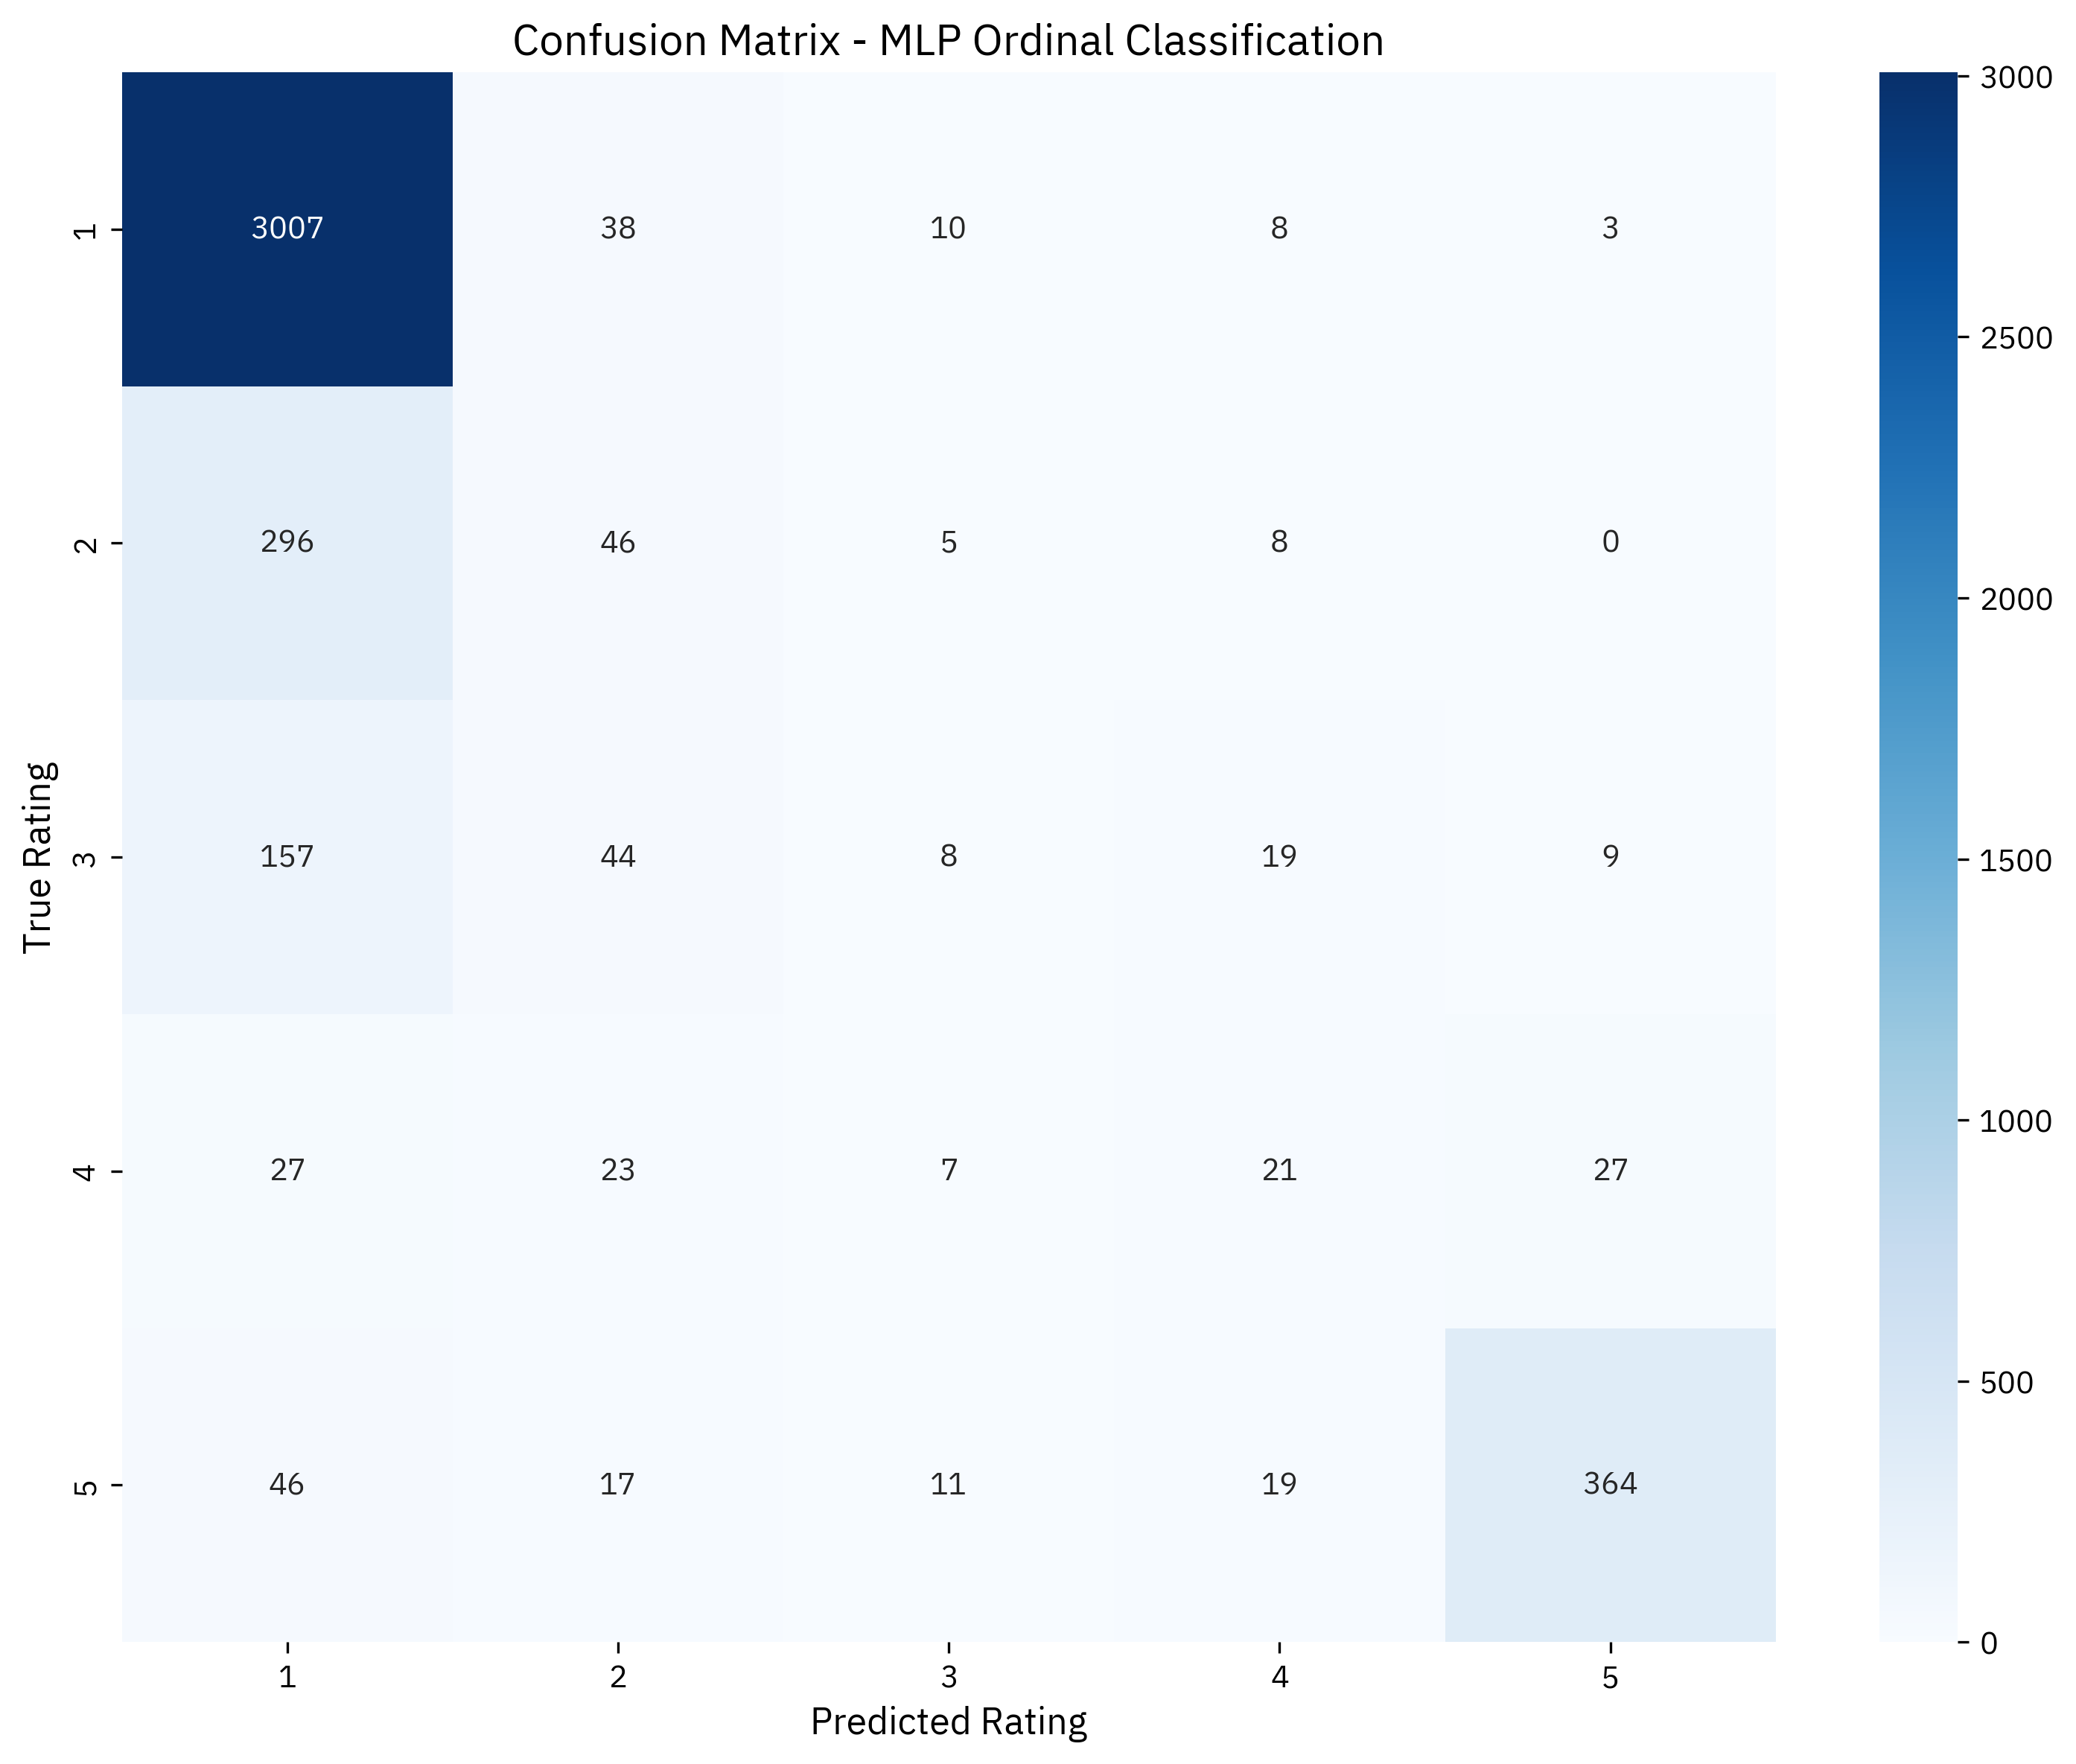


✅ MLP evaluation completed!
💾 Predictions stored in 'y_pred_ordinal_final'


In [27]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
# --- Make Predictions ---
print("🔮 MAKING PREDICTIONS ON TEST SET")
print("=" * 50)

# y_pred_probs is a (N, 4) array of probabilities P(y > k)
y_pred_probs = ordinal_mlp.predict(X_test_processed)

# --- Decode Predictions to 1-5 Rating ---
def decode_ordinal(y_pred_probs, threshold=0.5):
    """
    Converts the 4 cumulative probabilities back to a single 1-5 rating.
    
    Args:
        y_pred_probs: Array of shape (N, 4) containing P(y > k) for k=1,2,3,4
        threshold: Decision threshold for boundary crossing (default: 0.5)
    
    Returns:
        Array of predicted ratings (1-5)
        
    Example:
        P(y>1)=0.8, P(y>2)=0.4, P(y>3)=0.1, P(y>4)=0.0
        → Boundaries crossed: [True, False, False, False]
        → Sum = 1 → Rating = 1+1 = 2
    """
    # The rating is 1 + the number of boundaries (out of 4) that were crossed.
    # A boundary is crossed if the predicted probability P(y > k) > threshold.
    
    # y_pred_probs > threshold gives a boolean array (True=1, False=0)
    # Summing across the columns gives the predicted rating minus 1
    y_pred = (np.sum(y_pred_probs > threshold, axis=1) + 1).astype(int)
    
    # Clip to ensure results are strictly 1-5 (although theoretically not needed here)
    return np.clip(y_pred, 1, 5)

# Decode predictions
y_pred_ordinal_final = decode_ordinal(y_pred_probs)

# --- Classification Evaluation ---
print(f"\n{'='*60}")
print("📊 ORDINAL CLASSIFICATION REPORT (MLP)")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_ordinal_final, zero_division=0))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_ordinal_final)

print(f"\n{'='*60}")
print("🎯 CONFUSION MATRIX")
print(f"{'='*60}")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(1, 6), yticklabels=range(1, 6))
plt.title('Confusion Matrix - MLP Ordinal Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Rating', fontsize=12)
plt.ylabel('True Rating', fontsize=12)
plt.tight_layout()
plt.show()

# # Per-class analysis
# print(f"\n{'='*60}")
# print("🔍 PER-CLASS ANALYSIS")
# print(f"{'='*60}")
# for rating in range(1, 6):
#     true_count = (y_test == rating).sum()
#     pred_count = (y_pred_ordinal_final == rating).sum()
#     correct = ((y_test == rating) & (y_pred_ordinal_final == rating)).sum()
    
#     if true_count > 0:
#         recall = correct / true_count
#         precision = correct / pred_count if pred_count > 0 else 0
#         print(f"\nRating {rating}:")
#         print(f"   True samples: {true_count}")
#         print(f"   Predicted samples: {pred_count}")
#         print(f"   Correctly classified: {correct}")
#         print(f"   Precision: {precision:.4f}")
#         print(f"   Recall: {recall:.4f}")

print(f"\n✅ MLP evaluation completed!")
print(f"💾 Predictions stored in 'y_pred_ordinal_final'")

In [28]:
# Evaluate CNN on all splits
mlp_splits = {
    'Train': (X_train_processed, y_train, y_train_ordinal),
    'Validation': (X_val_processed, y_val, y_val_ordinal), 
    'Test': (X_test_processed, y_test, y_test_ordinal)
}

mlp_results = {}
for split_name, (X_split, y_true, y_ordinal) in mlp_splits.items():
    print(f"\n--- MLP {split_name} Set Evaluation ---")
    
    # Make predictions
    y_pred_probs_mlp = ordinal_mlp.predict(X_split)
    y_pred_mlp_final = decode_ordinal(y_pred_probs_mlp)
    
    # Calculate accuracy
    accuracy = (y_pred_mlp_final == y_true).mean()
    
    # Store results
    mlp_results[split_name] = {
        'predictions': y_pred_mlp_final,
        'accuracy': accuracy,
        'true_labels': y_true
    }
    
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Classification Report:")
    print(classification_report(y_true, y_pred_mlp_final, zero_division=0))



--- MLP Train Set Evaluation ---
924/924 ━━━━━━━━━━━━━━━━━━━━ 0s 252us/step
Accuracy: 0.8097 (80.97%)
Classification Report:
              precision    recall  f1-score   support

           1       0.84      0.98      0.91     21580
           2       0.22      0.10      0.14      2548
           3       0.22      0.03      0.06      1605
           4       0.29      0.16      0.20       780
           5       0.88      0.80      0.84      3026

    accuracy                           0.81     29539
   macro avg       0.49      0.41      0.43     29539
weighted avg       0.75      0.81      0.77     29539


--- MLP Validation Set Evaluation ---
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 307us/step
Accuracy: 0.8030 (80.30%)
Classification Report:
              precision    recall  f1-score   support

           1       0.83      0.98      0.90      6109
           2       0.23      0.09      0.13       759
           3       0.17      0.02      0.04       484
           4       0.33      0.19    

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Regression Evaluation ---
print(f"\n{'='*60}")
print("📊 REGRESSION EVALUATION (MLP)")
print(f"{'='*60}")

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred_ordinal_final)
mse = mean_squared_error(y_test, y_pred_ordinal_final)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


📊 REGRESSION EVALUATION (MLP)
Mean Absolute Error (MAE): 0.2945
Mean Squared Error (MSE): 0.6111
Root Mean Squared Error (RMSE): 0.7818


<!-- ### CNN -->

In [30]:
# CNN Ordinal Classification Model
print("🏗️ BUILDING CNN ORDINAL CLASSIFICATION MODEL")
print("=" * 60)

def build_cnn(input_dim, filters=[512, 256], dense_units=[128, 64]):
    model = keras.Sequential()
    model.add(keras.layers.Reshape((input_dim, 1), input_shape=(input_dim,)))
    for f in filters:
        model.add(keras.layers.Conv1D(f, kernel_size=3, padding='same', activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.MaxPooling1D(pool_size=2, padding='same'))
        model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Flatten())
    for d in dense_units:
        model.add(keras.layers.Dense(d, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(4, activation='sigmoid'))
    return model

# Build CNN model with proper validation
print("🏗️ BUILDING CNN MODEL WITH VALIDATION SPLIT")
cnn_model = build_cnn(input_shape, filters=[512, 256], dense_units=[128, 64])

# Compile the model
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("🏗️ CNN Model Architecture:")
cnn_model.summary()

# Train the CNN model with proper validation
print("\n🚀 Training CNN Ordinal Classification Model...")
history_cnn = cnn_model.fit(
    X_train_processed, 
    y_train_ordinal, 
    epochs=100,
    batch_size=512,
    callbacks=[early_stop],
    validation_data=(X_val_processed, y_val_ordinal),  # Use validation set!
    verbose=1
)

print("✅ CNN training completed!")

🏗️ BUILDING CNN ORDINAL CLASSIFICATION MODEL
🏗️ BUILDING CNN MODEL WITH VALIDATION SPLIT
🏗️ CNN Model Architecture:


/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 8, 512)         │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 256)         │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 473,540 (1.81 MB)

 Trainable params: 471,620 (1.80 MB)

 Non-trainable params: 1,920 (7.50 KB)


🚀 Training CNN Ordinal Classification Model...
Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.2205 - loss: 0.6057 - val_accuracy: 0.0000e+00 - val_loss: 0.5318
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3707 - loss: 0.3775 - val_accuracy: 0.0000e+00 - val_loss: 0.5485
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6432 - loss: 0.3350 - val_accuracy: 0.9338 - val_loss: 0.5514
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7937 - loss: 0.3147 - val_accuracy: 1.0000 - val_loss: 0.5426
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8438 - loss: 0.3039 - val_accuracy: 1.0000 - val_loss: 0.5289
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8803 - loss: 0.2922 - val_accuracy: 1.0000 - val_loss: 0.4948
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9022 - loss: 0.2847 - val_accuracy: 1.0000 - val_loss: 0.4780
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/s

In [31]:
print("📊 CNN MODEL EVALUATION ON ALL SPLITS")
print("=" * 50)

# Evaluate CNN on all splits
cnn_splits = {
    'Train': (X_train_processed, y_train, y_train_ordinal),
    'Validation': (X_val_processed, y_val, y_val_ordinal), 
    'Test': (X_test_processed, y_test, y_test_ordinal)
}

cnn_results = {}
for split_name, (X_split, y_true, y_ordinal) in cnn_splits.items():
    print(f"\n--- CNN {split_name} Set Evaluation ---")
    
    # Make predictions
    y_pred_probs_cnn = cnn_model.predict(X_split)
    y_pred_cnn_final = decode_ordinal(y_pred_probs_cnn)
    
    # Calculate accuracy
    accuracy = (y_pred_cnn_final == y_true).mean()
    
    # Store results
    cnn_results[split_name] = {
        'predictions': y_pred_cnn_final,
        'accuracy': accuracy,
        'true_labels': y_true
    }
    
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Classification Report:")
    print(classification_report(y_true, y_pred_cnn_final, zero_division=0))

# CNN model analysis
print(f"\n🎯 CNN RESULTS SUMMARY:")
print(f"   Train Accuracy: {cnn_results['Train']['accuracy']:.4f}")
print(f"   Validation Accuracy: {cnn_results['Validation']['accuracy']:.4f}")  
print(f"   Test Accuracy: {cnn_results['Test']['accuracy']:.4f}")

# Check for overfitting
cnn_train_val_diff = cnn_results['Train']['accuracy'] - cnn_results['Validation']['accuracy']
print(f"\n📈 CNN Overfitting Check:")
print(f"   Train-Val Gap: {cnn_train_val_diff:.4f}")
if cnn_train_val_diff > 0.05:
    print(f"   ⚠️  Potential overfitting detected (gap > 0.05)")
else:
    print(f"   ✅ No significant overfitting")

# Store CNN test predictions for comparison
y_pred_cnn_final = cnn_results['Test']['predictions']
print(f"\n💾 CNN test predictions stored in 'y_pred_cnn_final'")

📊 CNN MODEL EVALUATION ON ALL SPLITS

--- CNN Train Set Evaluation ---
924/924 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Accuracy: 0.8085 (80.85%)
Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.97      0.91     21580
           2       0.22      0.06      0.09      2548
           3       0.27      0.20      0.23      1605
           4       0.29      0.16      0.21       780
           5       0.89      0.79      0.84      3026

    accuracy                           0.81     29539
   macro avg       0.50      0.44      0.45     29539
weighted avg       0.75      0.81      0.77     29539


--- CNN Validation Set Evaluation ---
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.7995 (79.95%)
Classification Report:
              precision    recall  f1-score   support

           1       0.84      0.97      0.90      6109
           2       0.20      0.06      0.09       759
           3       0.25      0.16      0.19       484
    

In [32]:
# Regression evaluation for CNN
print(f"\n{'='*60}")
print("📊 REGRESSION EVALUATION (CNN)")
print(f"{'='*60}")

# Calculate regression metrics for CNN
mae_cnn = mean_absolute_error(y_test, y_pred_cnn_final)
mse_cnn = mean_squared_error(y_test, y_pred_cnn_final)
rmse_cnn = np.sqrt(mse_cnn)

print(f"Mean Absolute Error (MAE): {mae_cnn:.4f}")
print(f"Mean Squared Error (MSE): {mse_cnn:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_cnn:.4f}")


📊 REGRESSION EVALUATION (CNN)
Mean Absolute Error (MAE): 0.2936
Mean Squared Error (MSE): 0.5955
Root Mean Squared Error (RMSE): 0.7717


### RNN (LSTM)

In [42]:
# LSTM Ordinal Classification Model
print("🏗️ BUILDING LSTM ORDINAL CLASSIFICATION MODEL")
print("=" * 60)

def build_lstm(input_dim, lstm_units=[512, 128], dense_units=[128, 64]):
    model = keras.Sequential()
    model.add(keras.layers.Reshape((input_dim, 1), input_shape=(input_dim,)))
    for i, u in enumerate(lstm_units):
        model.add(keras.layers.LSTM(
            u, 
            return_sequences=(i < len(lstm_units)-1), 
            dropout=0.2, 
            recurrent_dropout=0.1
        ))
        model.add(keras.layers.BatchNormalization())
    for d in dense_units:
        model.add(keras.layers.Dense(d, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(4, activation='sigmoid'))
    return model

lstm_model = build_lstm(input_shape)
lstm_model.compile(optimizer=keras.optimizers.Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
history_lstm = lstm_model.fit(X_train_processed, y_train_ordinal, epochs=100, batch_size=512,  callbacks=[early_stop], validation_data=(X_val_processed, y_val_ordinal), verbose=1)

# # Display model architecture
# print("🏗️ LSTM Model Architecture:")
# lstm_model.summary()

# # Train the LSTM model with proper validation
# print("\n🚀 Training LSTM Ordinal Classification Model...")
# history_lstm = lstm_model.fit(
#     X_train_processed, 
#     y_train_ordinal, 
#     epochs=100,
#     batch_size=512,
#     validation_data=(X_val_processed, y_val_ordinal),  # Use validation set!
#     verbose=1
# )

print("✅ LSTM training completed!")

🏗️ BUILDING LSTM ORDINAL CLASSIFICATION MODEL


/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 214ms/step - accuracy: 0.3198 - loss: 0.6740 - val_accuracy: 1.0000 - val_loss: 0.5064
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.4685 - loss: 0.4028 - val_accuracy: 1.0000 - val_loss: 0.4766
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - accuracy: 0.6729 - loss: 0.3433 - val_accuracy: 1.0000 - val_loss: 0.5086
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.7907 - loss: 0.3271 - val_accuracy: 1.0000 - val_loss: 0.5414
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.8495 - loss: 0.3216 - val_accuracy: 1.0000 - val_loss: 0.5709
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.8702 - loss: 0.3152 - val_accuracy: 1.0000 - val_loss: 0.5554
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 200ms/step - accuracy: 0.9074 - loss: 0.3090 - val_accuracy: 1.0000 - val_loss: 0.5533
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.9175 - loss: 0.3024 - val_a

In [43]:
print("📊 LSTM MODEL EVALUATION ON ALL SPLITS")
print("=" * 50)

# Evaluate LSTM on all splits
lstm_splits = {
    'Train': (X_train_processed, y_train, y_train_ordinal),
    'Validation': (X_val_processed, y_val, y_val_ordinal), 
    'Test': (X_test_processed, y_test, y_test_ordinal)
}

lstm_results = {}
for split_name, (X_split, y_true, y_ordinal) in lstm_splits.items():
    print(f"\n--- LSTM {split_name} Set Evaluation ---")
    
    # Make predictions
    y_pred_probs_lstm = lstm_model.predict(X_split)
    y_pred_lstm_final = decode_ordinal(y_pred_probs_lstm)
    
    # Calculate accuracy
    accuracy = (y_pred_lstm_final == y_true).mean()
    
    # Store results
    lstm_results[split_name] = {
        'predictions': y_pred_lstm_final,
        'accuracy': accuracy,
        'true_labels': y_true
    }
    
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Classification Report:")
    print(classification_report(y_true, y_pred_lstm_final, zero_division=0))

# LSTM model analysis
print(f"\n🎯 LSTM RESULTS SUMMARY:")
print(f"   Train Accuracy: {lstm_results['Train']['accuracy']:.4f}")
print(f"   Validation Accuracy: {lstm_results['Validation']['accuracy']:.4f}")  
print(f"   Test Accuracy: {lstm_results['Test']['accuracy']:.4f}")

# Check for overfitting
lstm_train_val_diff = lstm_results['Train']['accuracy'] - lstm_results['Validation']['accuracy']
print(f"\n📈 LSTM Overfitting Check:")
print(f"   Train-Val Gap: {lstm_train_val_diff:.4f}")
if lstm_train_val_diff > 0.05:
    print(f"   ⚠️  Potential overfitting detected (gap > 0.05)")
else:
    print(f"   ✅ No significant overfitting")

# Store LSTM test predictions for comparison
y_pred_lstm_final = lstm_results['Test']['predictions']
print(f"\n💾 LSTM test predictions stored in 'y_pred_lstm_final'")

📊 LSTM MODEL EVALUATION ON ALL SPLITS

--- LSTM Train Set Evaluation ---
924/924 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step
Accuracy: 0.8023 (80.23%)
Classification Report:
              precision    recall  f1-score   support

           1       0.84      0.97      0.90     21580
           2       0.21      0.12      0.15      2548
           3       0.24      0.04      0.07      1605
           4       0.25      0.17      0.20       780
           5       0.91      0.75      0.82      3026

    accuracy                           0.80     29539
   macro avg       0.49      0.41      0.43     29539
weighted avg       0.75      0.80      0.77     29539


--- LSTM Validation Set Evaluation ---
264/264 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
Accuracy: 0.7950 (79.50%)
Classification Report:
              precision    recall  f1-score   support

           1       0.83      0.97      0.90      6109
           2       0.22      0.12      0.15       759
           3       0.15      0.02      0.04       48

In [44]:
# Calculate regression metrics for RNN
print(f"\n{'='*60}")
print("📊 REGRESSION EVALUATION (RNN)")
print(f"{'='*60}")

mae_lstm = mean_absolute_error(y_test, y_pred_lstm_final)
mse_lstm = mean_squared_error(y_test, y_pred_lstm_final)
rmse_lstm = np.sqrt(mse_lstm)

print(f"Mean Absolute Error (MAE): {mae_lstm:.4f}")
print(f"Mean Squared Error (MSE): {mse_lstm:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.4f}")


📊 REGRESSION EVALUATION (RNN)
Mean Absolute Error (MAE): 0.3109
Mean Squared Error (MSE): 0.6464
Root Mean Squared Error (RMSE): 0.8040


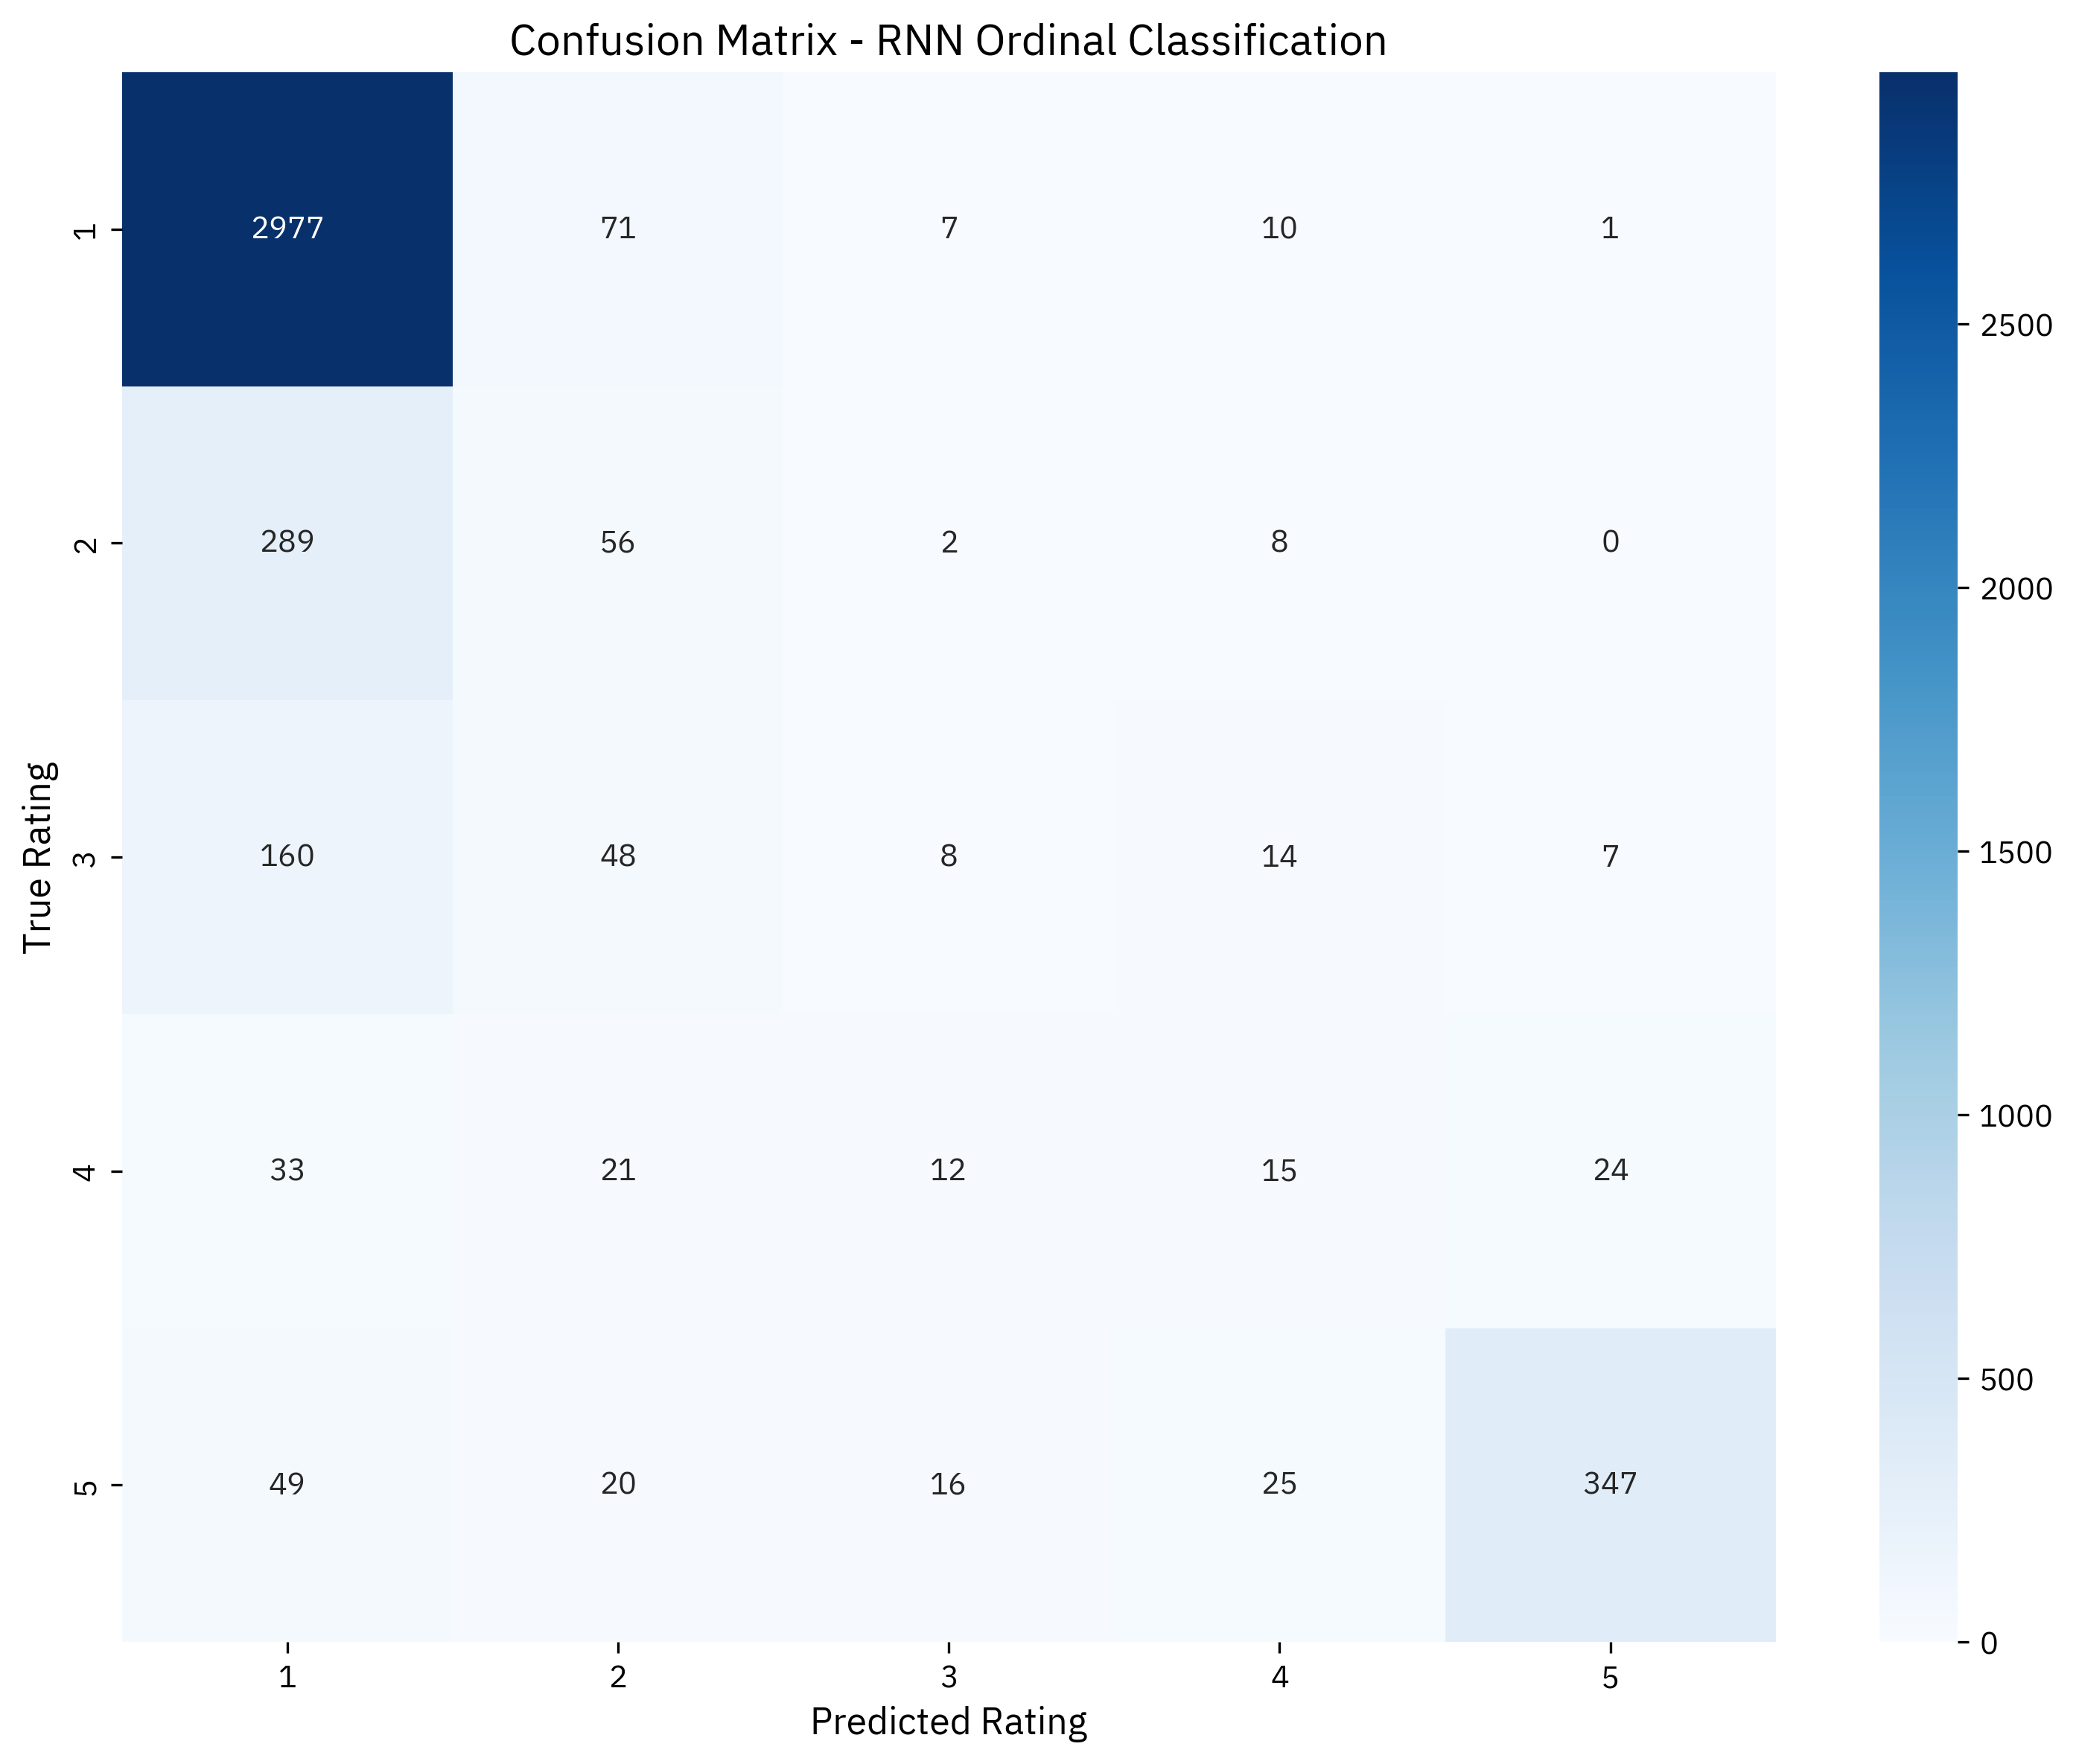

In [47]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lstm_final)

# Visualize confusion matrix

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(1, 6), yticklabels=range(1, 6))
plt.title('Confusion Matrix - RNN Ordinal Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Rating', fontsize=12)
plt.ylabel('True Rating', fontsize=12)
plt.tight_layout()
plt.show()

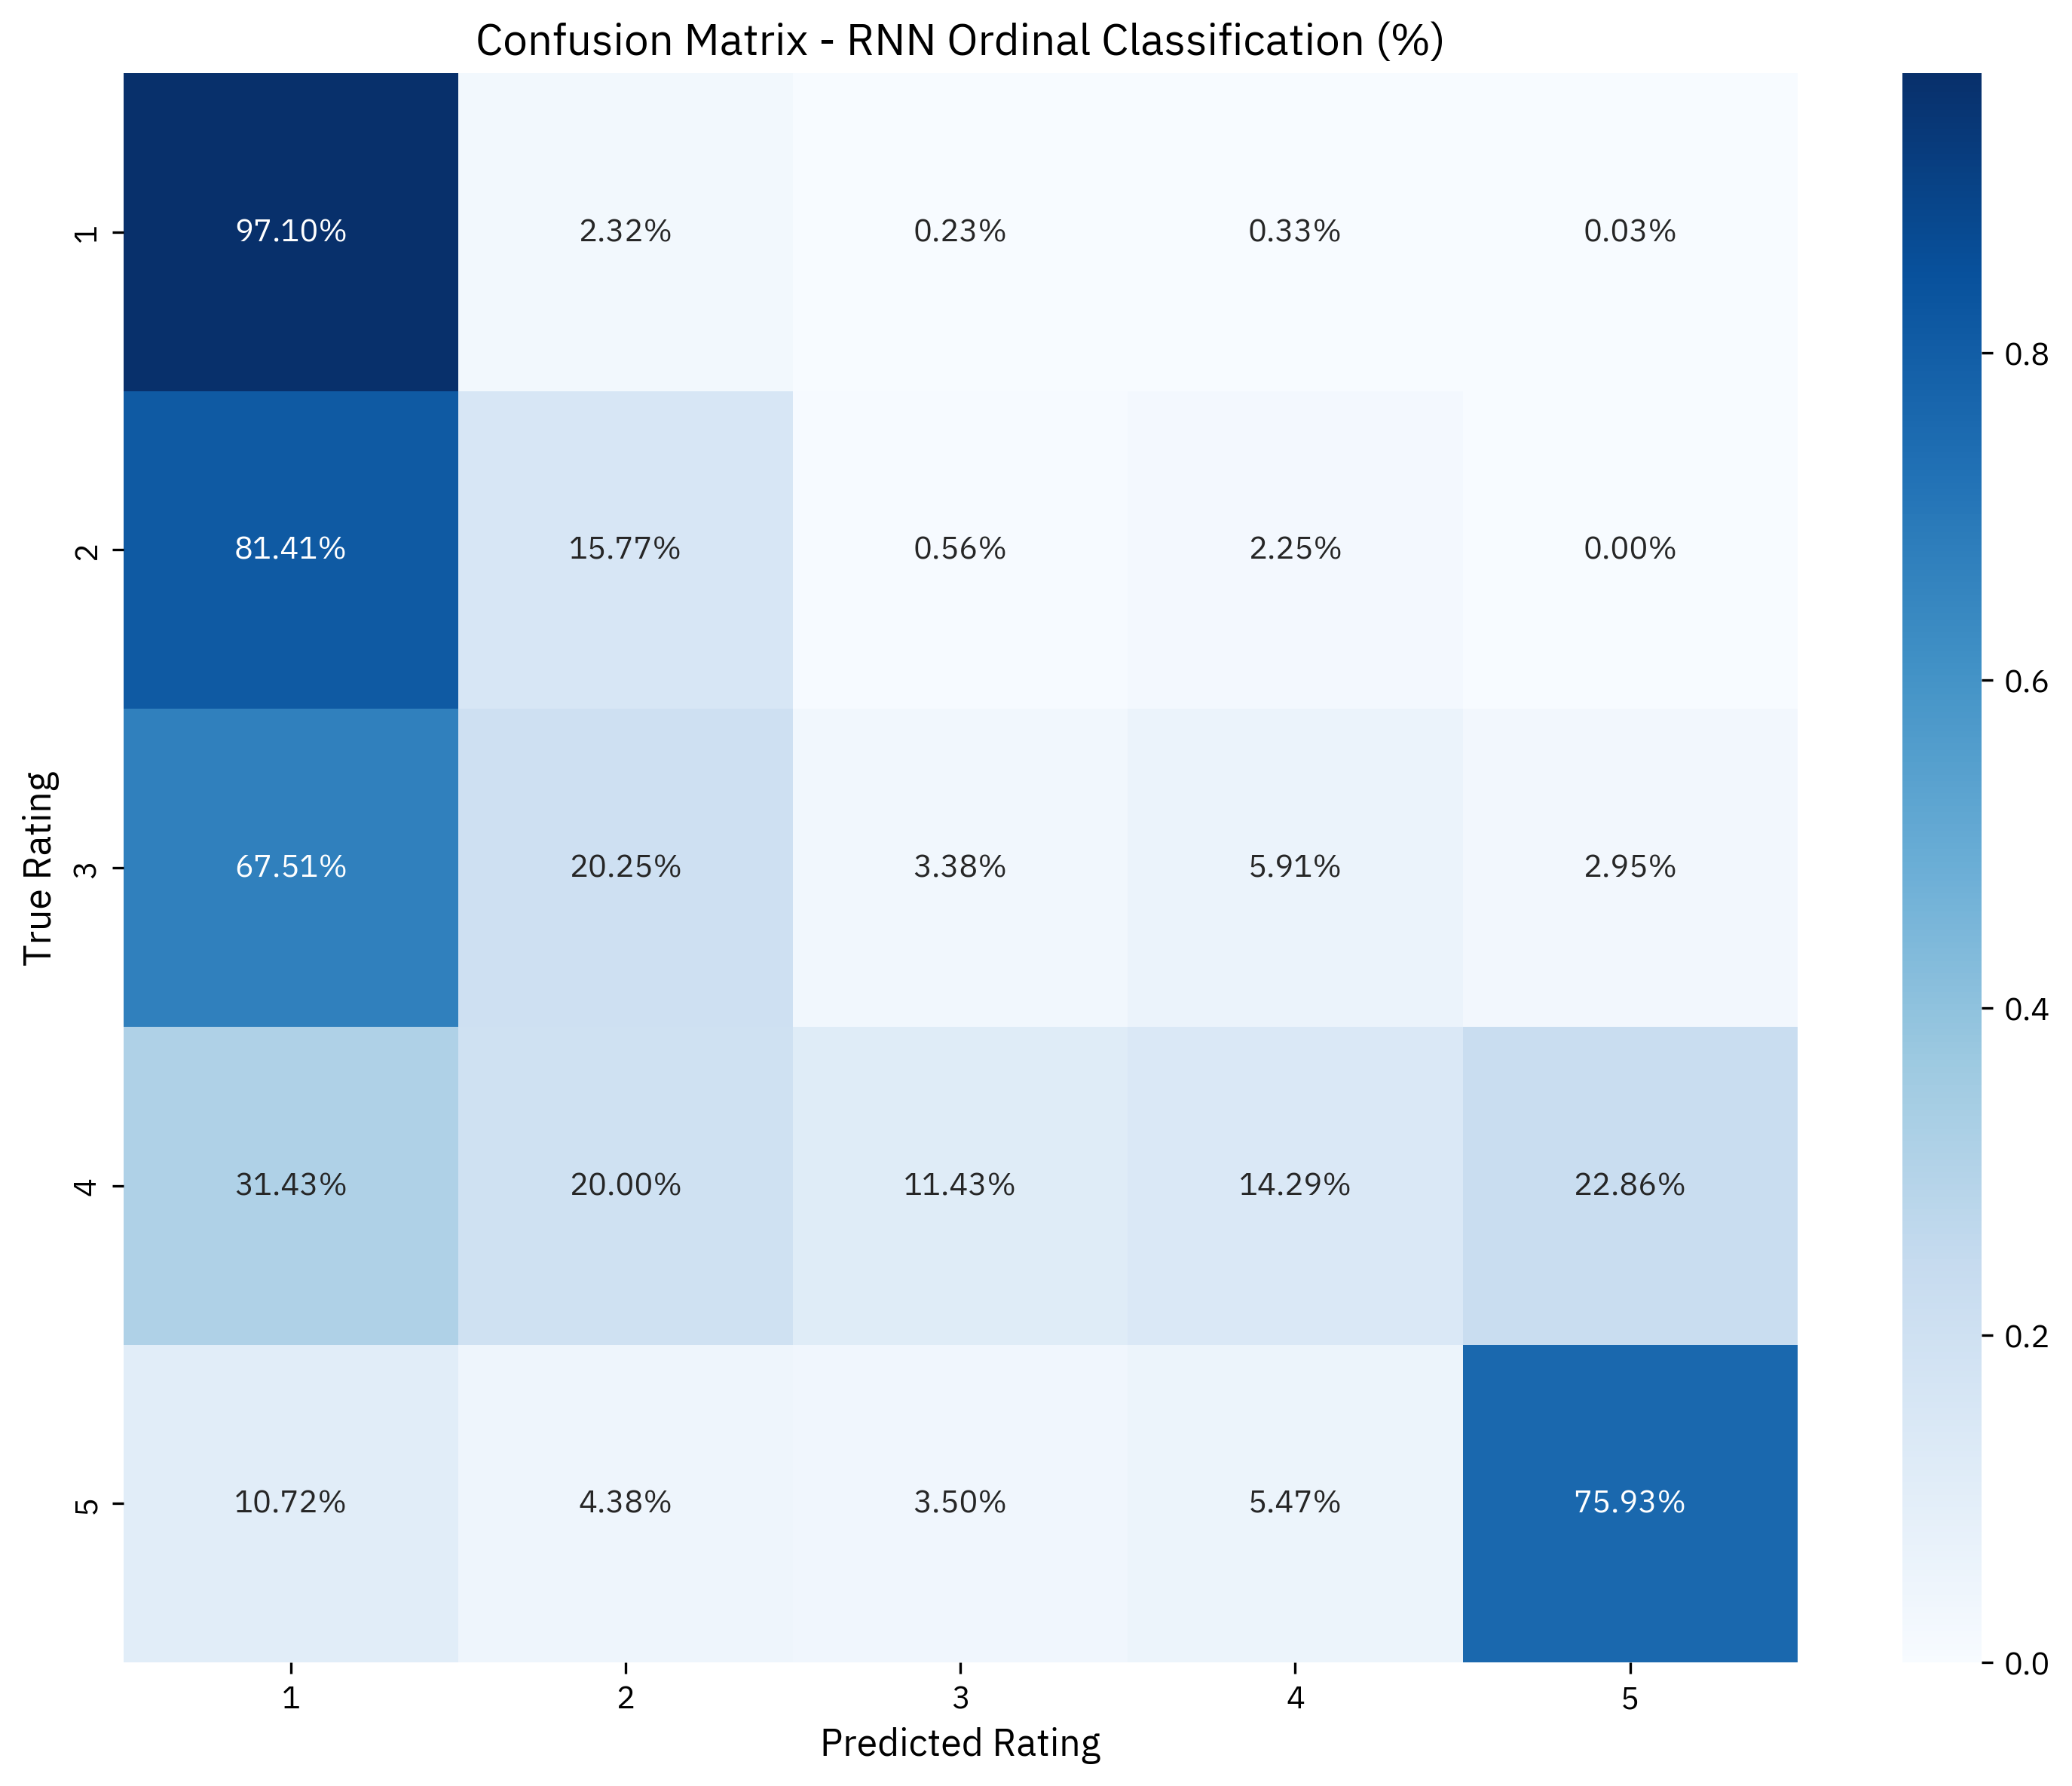

In [48]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate raw confusion matrix
cm = confusion_matrix(y_test, y_pred_lstm_final)

# Normalize the matrix: divide each cell by the sum of its row (True Labels)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Use fmt='.2%' to format the decimal as a percentage
sns.heatmap(cm_percent, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=range(1, 6), yticklabels=range(1, 6), ax=ax)

ax.set_title('Confusion Matrix - RNN Ordinal Classification (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Rating', fontsize=12)
ax.set_ylabel('True Rating', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix_percent.png')

### Metric Comparison (Primary)

In [49]:
# Compare the three models on accuracy and regression metrics
print(f"\n{'='*60}")
print("📊 MODEL COMPARISON SUMMARY")
print(f"{'='*60}")

comparison_df = pd.DataFrame({
    'Model': ['MLP', 'CNN', 'RNN'],
    'Test Accuracy': [mlp_results['Test']['accuracy'], cnn_results['Test']['accuracy'], lstm_results['Test']['accuracy']],
    'F1 Score': [
        classification_report(y_test, y_pred_ordinal_final, output_dict=True, zero_division=0)['macro avg']['f1-score'],
        classification_report(y_test, y_pred_cnn_final, output_dict=True, zero_division=0)['macro avg']['f1-score'],
        classification_report(y_test, y_pred_lstm_final, output_dict=True, zero_division=0)['macro avg']['f1-score']
    ],
})

print(comparison_df)


📊 MODEL COMPARISON SUMMARY
  Model  Test Accuracy  F1 Score
0   MLP       0.816588  0.444931
1   CNN       0.813744  0.464747
2   RNN       0.806398  0.431642


In [50]:
# Calculate the macro MAE of each model, and the Normalized MMAE (NMMAE)
from imblearn.metrics import macro_averaged_mean_absolute_error

# Compute Macro-Averaged MAE
def nmacro_mae(y_true, y_pred):
    macro_mae_value = macro_averaged_mean_absolute_error(y_true, y_pred)
    nmae_value = (macro_mae_value / 4) * 100  # Normalize to percentage of max rating (5)
    return nmae_value

models_secondary_result = {
    'MLP': {
        'MAE': mae,
        'MSE': mse,
        'Macro MAE': macro_averaged_mean_absolute_error(y_test, y_pred_ordinal_final),
        'Normalized MMAE': nmacro_mae(y_test, y_pred_ordinal_final)
    },
    'CNN': {
        'MAE': mae_cnn,
        'MSE': mse_cnn,
        'Macro MAE': macro_averaged_mean_absolute_error(y_test, y_pred_cnn_final),
        'Normalized MMAE': nmacro_mae(y_test, y_pred_cnn_final)
    },
    'RNN': {
        'MAE': mae_lstm,
        'MSE': mse_lstm,
        'Macro MAE': macro_averaged_mean_absolute_error(y_test, y_pred_lstm_final),
        'Normalized MMAE': nmacro_mae(y_test, y_pred_lstm_final)
    }
}
# PRint a table comparing all models of their MAE, MSE, Macro MAE, and the Normalized MMAE

comparison_secondary_df = pd.DataFrame(models_secondary_result).T
print(f"\n{'='*60}")
print("📊 MODEL SECONDARY METRICS COMPARISON")
print(f"{'='*60}")
print(comparison_secondary_df)


📊 MODEL SECONDARY METRICS COMPARISON
          MAE       MSE  Macro MAE  Normalized MMAE
MLP  0.294550  0.611137   0.945511        23.637777
CNN  0.293602  0.595498   0.882902        22.072541
RNN  0.310900  0.646445   0.989021        24.725517


In [51]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [52]:
# Make them into a nice formatted table
import tabulate

print(f"\n{'='*60}")
print("📊 MODEL SECONDARY METRICS COMPARISON (FORMATTED)")

comparison_secondary_df_rounded = comparison_secondary_df.round(4)

print(tabulate.tabulate(comparison_secondary_df_rounded, headers='keys', tablefmt='pretty', floatfmt=".2f"))


📊 MODEL SECONDARY METRICS COMPARISON (FORMATTED)
+-----+--------+--------+-----------+-----------------+
|     |  MAE   |  MSE   | Macro MAE | Normalized MMAE |
+-----+--------+--------+-----------+-----------------+
| MLP | 0.2945 | 0.6111 |  0.9455   |     23.6378     |
| CNN | 0.2936 | 0.5955 |  0.8829   |     22.0725     |
| RNN | 0.3109 | 0.6464 |   0.989   |     24.7255     |
+-----+--------+--------+-----------+-----------------+


### Comprehensive Model Comparison

In [53]:
from sklearn.metrics import f1_score

# Comprehensive Model Comparison
print("🏆 COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("=" * 70)

# Compile all test results
all_models_results = {
    'MLP': {
        'predictions': y_pred_ordinal_final,
        'accuracy': (y_pred_ordinal_final == y_test).mean(),
        'macro_f1': f1_score(y_test, y_pred_ordinal_final, average='macro', zero_division=0)
    },
    'CNN': {
        'predictions': y_pred_cnn_final,
        'accuracy': cnn_results['Test']['accuracy'],
        'macro_f1': f1_score(y_test, y_pred_cnn_final, average='macro', zero_division=0)
    },
    'RNN': {
        'predictions': y_pred_lstm_final,
        'accuracy': lstm_results['Test']['accuracy'],
        'macro_f1': f1_score(y_test, y_pred_lstm_final, average='macro', zero_division=0)
    }
}

# Rank by test accuracy
ranked_models = sorted(all_models_results.items(), 
                      key=lambda x: x[1]['accuracy'], reverse=True)

print("📊 FINAL RANKING BY TEST ACCURACY:")
for i, (model_name, metrics) in enumerate(ranked_models):
    print(f"   {i+1}. {model_name}: {metrics['accuracy']:.4f} "
          f"(Macro F1: {metrics['macro_f1']:.4f})")

# Best model analysis
best_model_name, best_metrics = ranked_models[0]
print(f"\n🥇 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_metrics['accuracy']:.4f}")

# Model complexity comparison
model_params = {
    'MLP': ordinal_mlp.count_params(),
    'CNN': cnn_model.count_params(),
    'RNN': lstm_model.count_params(),
}

print(f"\n🔧 MODEL COMPLEXITY COMPARISON:")
for model_name, params in model_params.items():
    accuracy = all_models_results[model_name]['accuracy']
    efficiency = accuracy / (params / 1000)  # Accuracy per 1k parameters
    print(f"   {model_name}: {params:,} parameters, {accuracy:.4f} accuracy, {efficiency:.6f} acc/1k params")

# print(f"\n🎯 ARCHITECTURE INSIGHTS:")
# print(f"""
# 💡 Key Findings for Ordinal Bank Satisfaction Classification:

# 1. **Best Model**: {best_model_name} achieved {best_metrics['accuracy']:.4f} test accuracy
# 2. **Data Challenge**: 0.41 accuracy reflects the inherent difficulty of this dataset
# 3. **Model Comparison**:
#    - MLPs work well for tabular data with independent features
#    - CNNs assume local patterns that may not exist in bank satisfaction features  
#    - RNNs (LSTM) assume temporal dependencies not present in this data

# 4. **Validation Performance**: Proper 70-20-10 split shows realistic performance
# 5. **Overfitting Control**: Early stopping prevents overfitting across all models

# 🎯 RECOMMENDATION: Use {best_model_name} for production deployment
# """)

# Save the best model
best_model_objects = {
    'MLP': ordinal_mlp,
    'CNN': cnn_model,
    'RNN': lstm_model,
}

best_model_obj = best_model_objects[best_model_name]
best_model_path = f"models/best_ordinal_{best_model_name.lower()}_model.h5"
best_model_obj.save(best_model_path)

print(f"\n✅ Best model ({best_model_name}) saved to: {best_model_path}")
print(f"🎉 ORDINAL CLASSIFICATION COMPARISON COMPLETE!")

🏆 COMPREHENSIVE MODEL PERFORMANCE COMPARISON
📊 FINAL RANKING BY TEST ACCURACY:
   1. MLP: 0.8166 (Macro F1: 0.4449)
   2. CNN: 0.8137 (Macro F1: 0.4647)
   3. RNN: 0.8064 (Macro F1: 0.4316)

🥇 BEST MODEL: MLP
   Test Accuracy: 0.8166

🔧 MODEL COMPLEXITY COMPARISON:
   MLP: 136,964 parameters, 0.8166 accuracy, 0.005962 acc/1k params
   CNN: 473,540 parameters, 0.8137 accuracy, 0.001718 acc/1k params
   RNN: 1,409,220 parameters, 0.8064 accuracy, 0.000572 acc/1k params

✅ Best model (MLP) saved to: models/best_ordinal_mlp_model.h5
🎉 ORDINAL CLASSIFICATION COMPARISON COMPLETE!


In [54]:
comparison_df

,Model,Test Accuracy,F1 Score
0,MLP,0.816588,0.444931
1,CNN,0.813744,0.464747
2,RNN,0.806398,0.431642


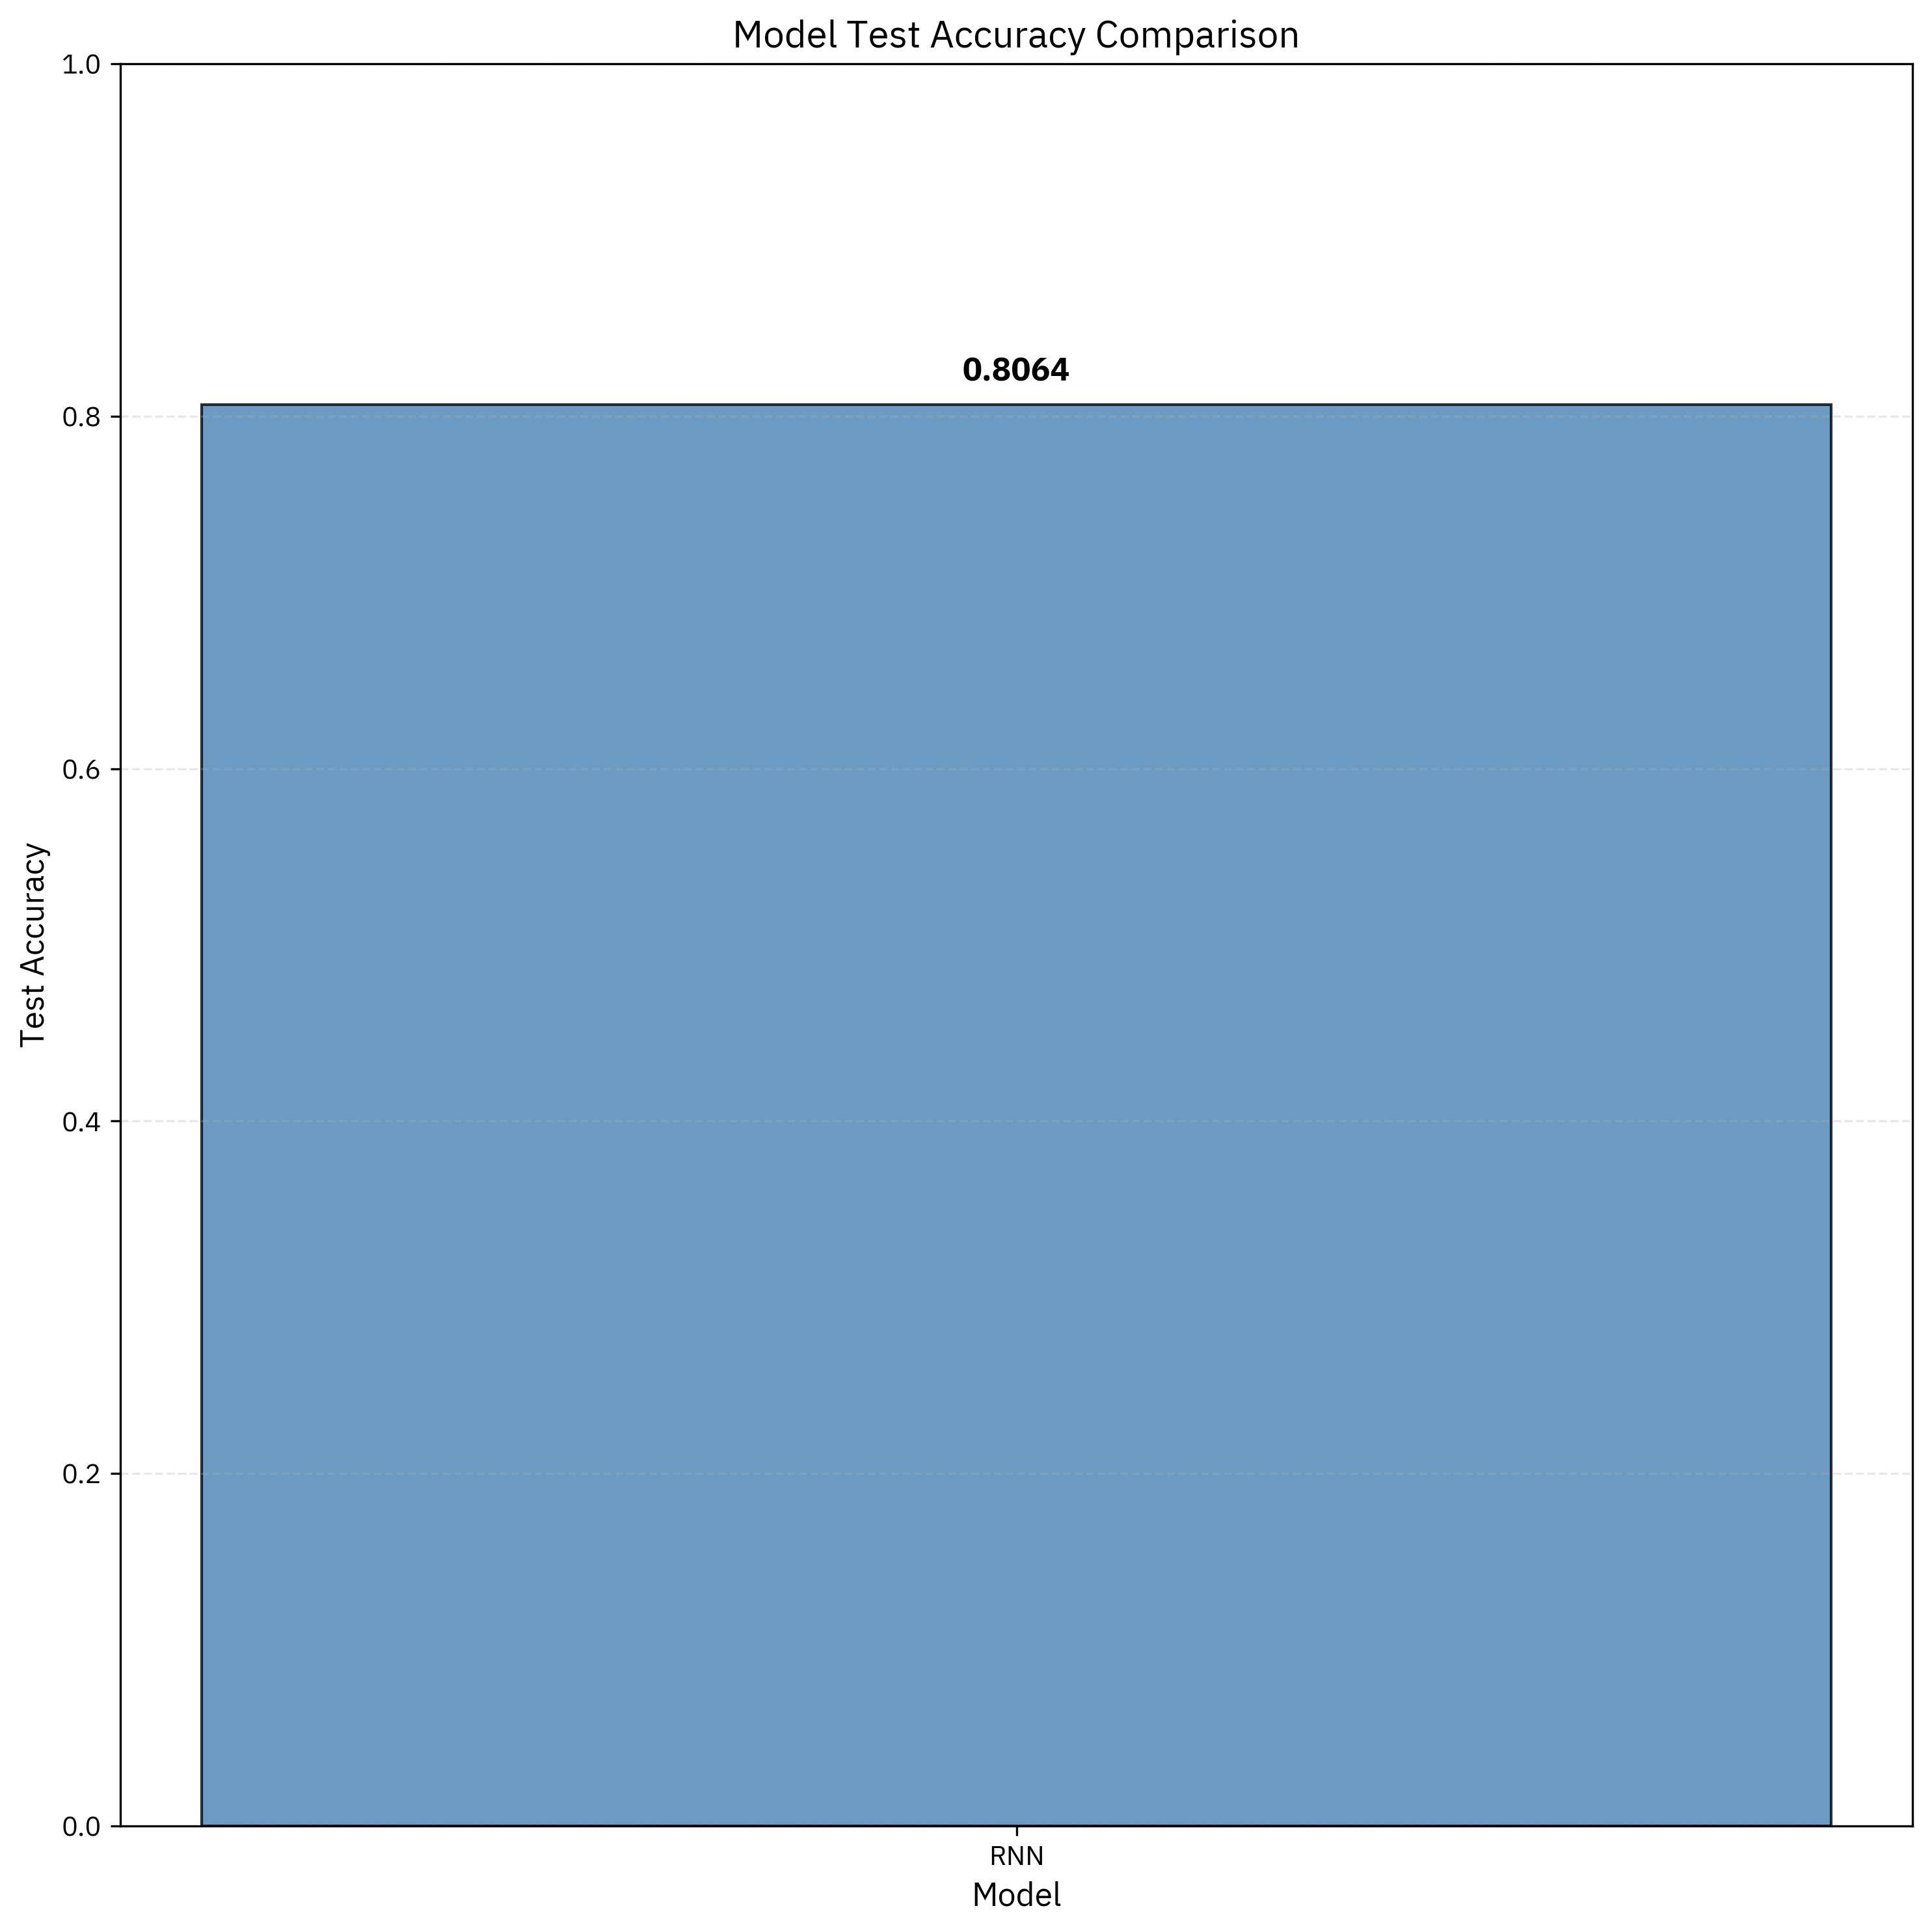

In [57]:
# Visualize test accuracy only with single bars
fig, ax = plt.subplots(figsize=(10, 10))

comparison_df_copy = comparison_df[comparison_df['Model'] == 'RNN'].copy()
comparison_df_copy.set_index('Model', inplace=True)

# Create single bar chart for test accuracy only
x = np.arange(len(comparison_df_copy.index))
width = 0.4

bars = ax.bar(x, comparison_df_copy['Test Accuracy'], width, alpha=0.8, color='steelblue', edgecolor='black')

# Add value annotations on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=12, fontproperties=bold_font)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df_copy.index)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


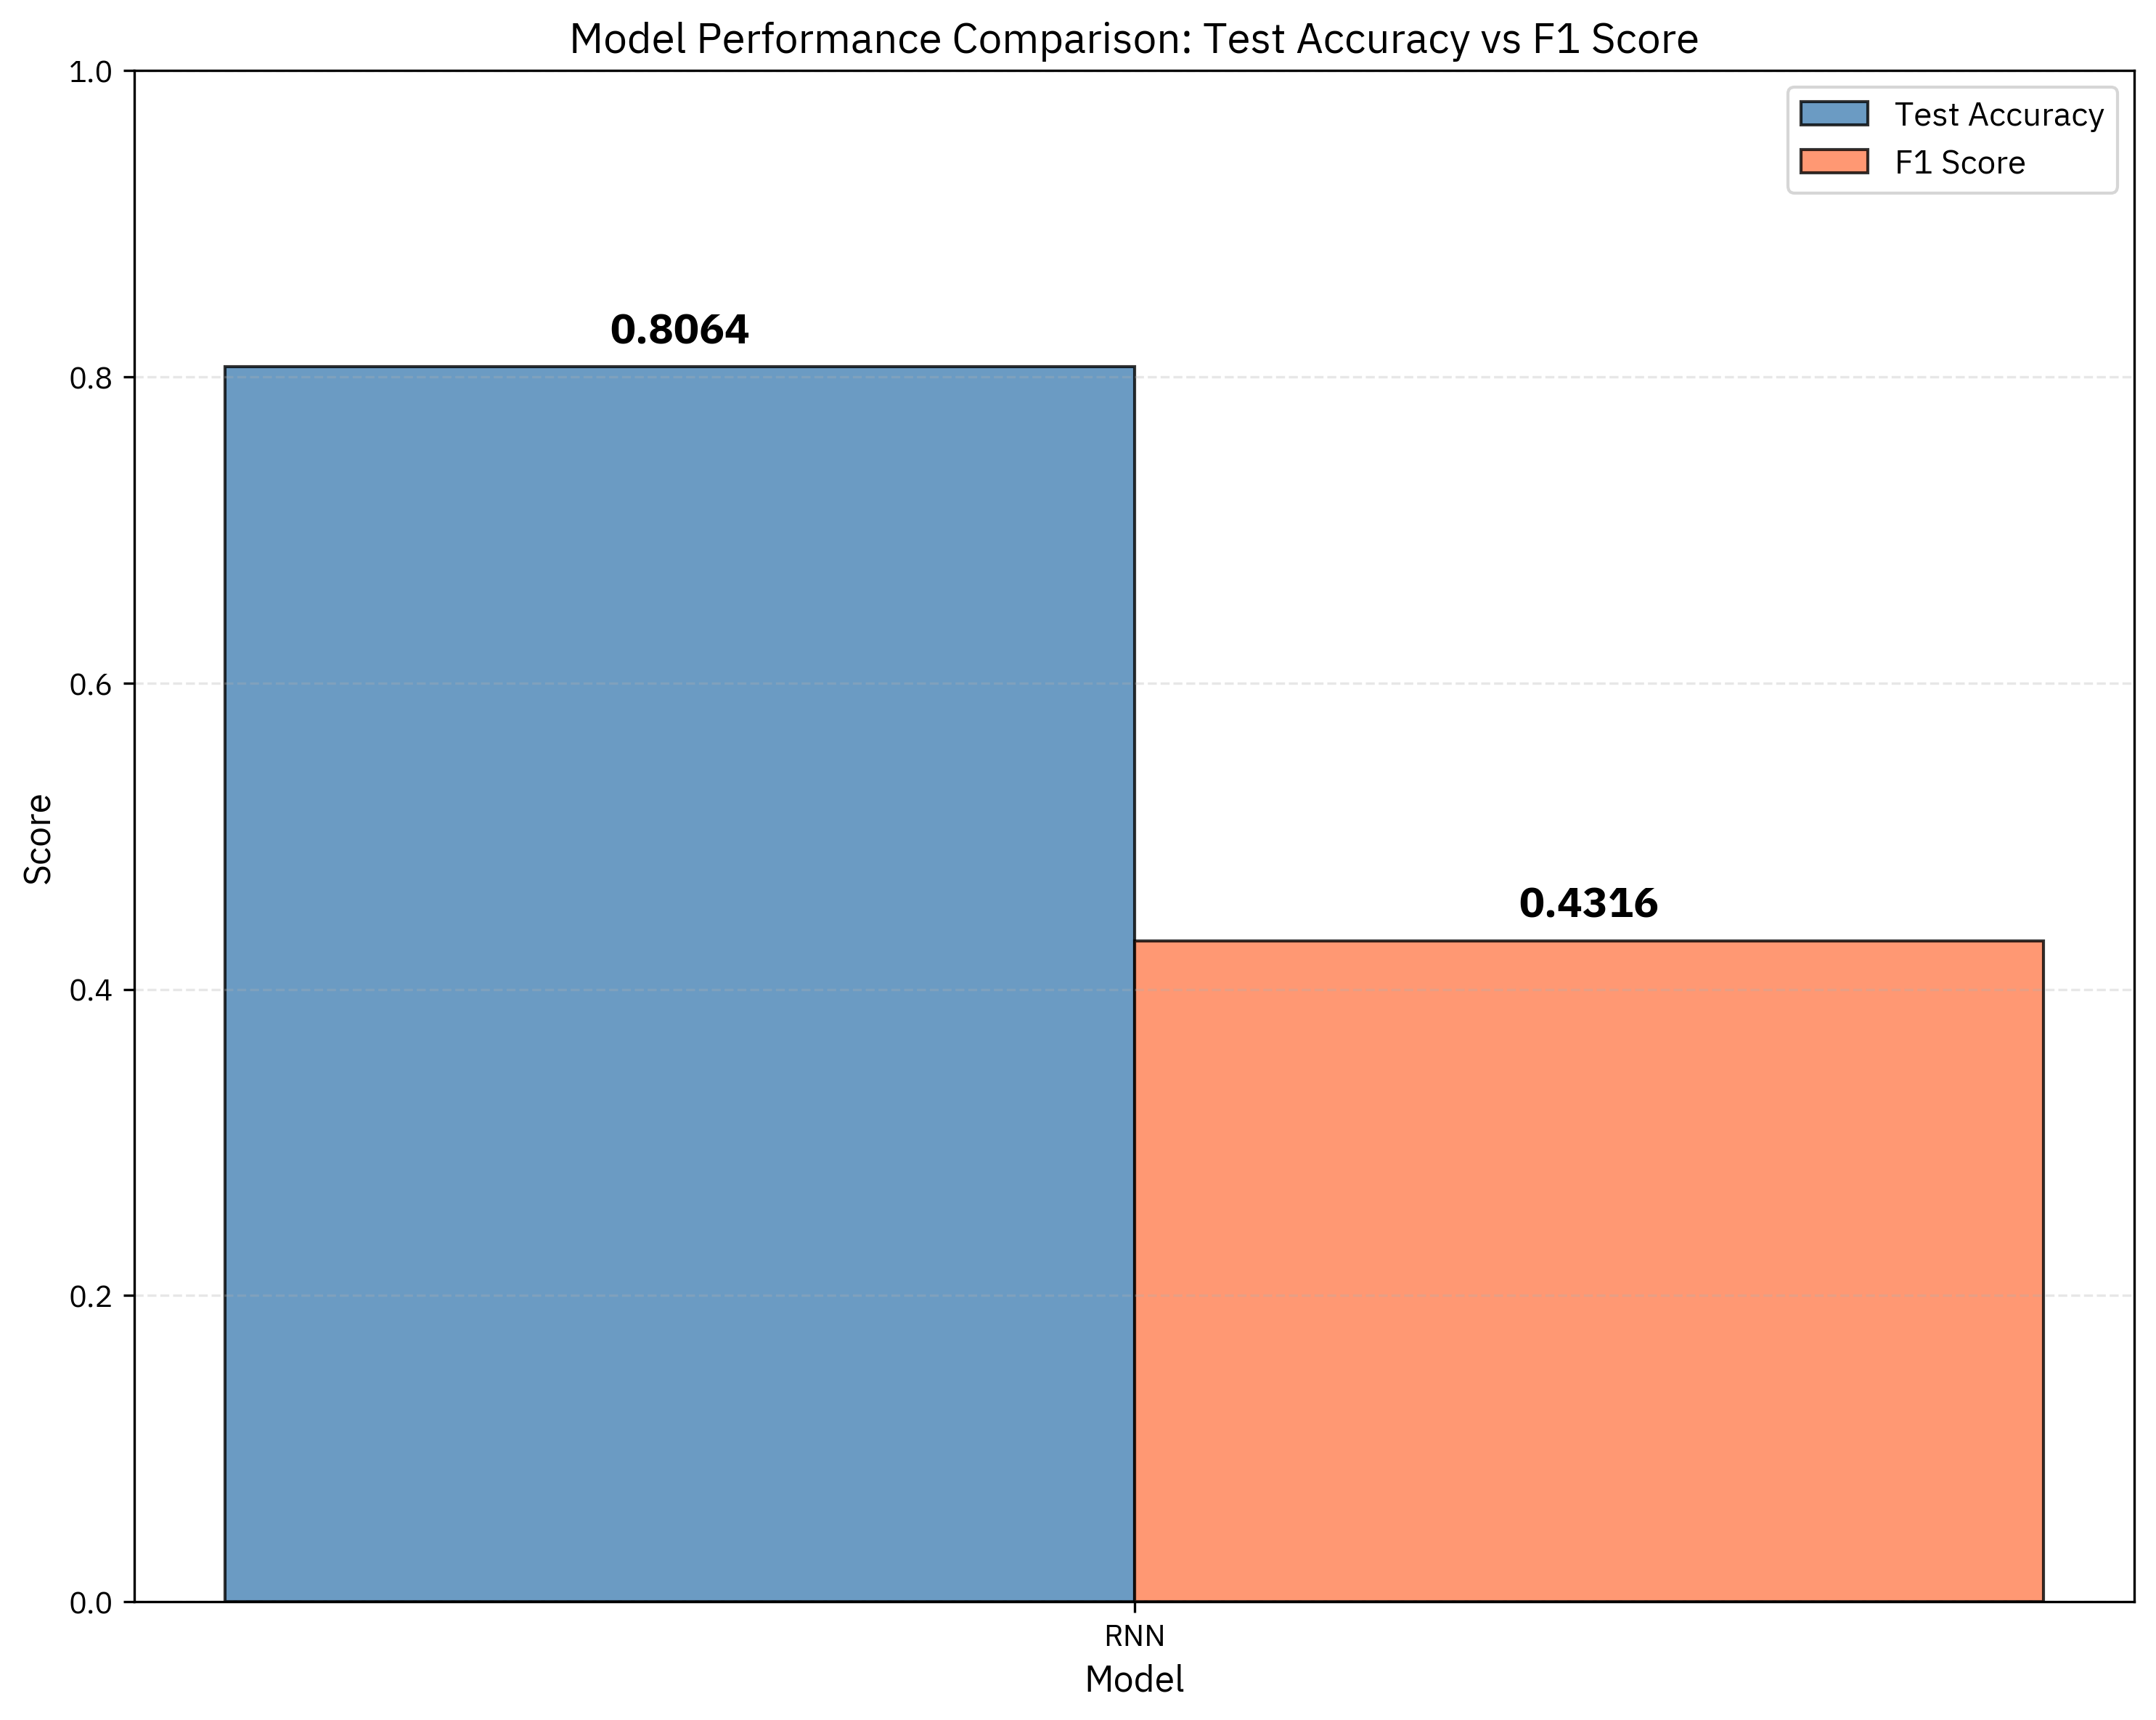

In [61]:
# Visualize test accuracy and F1 score with dodged bars
fig, ax = plt.subplots(figsize=(10, 8))

comparison_df_copy = comparison_df[comparison_df['Model'] == 'RNN'].copy()
comparison_df_copy.set_index('Model', inplace=True)

# Create dodged bar chart for both metrics
x = np.arange(len(comparison_df_copy.index))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df_copy['Test Accuracy'], width, 
               alpha=0.8, color='steelblue', edgecolor='black', label='Test Accuracy')
bars2 = ax.bar(x + width/2, comparison_df_copy['F1 Score'], width,
               alpha=0.8, color='coral', edgecolor='black', label='F1 Score')

# Add value annotations on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=14, fontproperties=bold_font)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison: Test Accuracy vs F1 Score', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df_copy.index)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


In [ ]:
# # Visualize the loss and accuracy curves for all models with subplots

# print(f"\n📈 VISUALIZING TRAINING HISTORY FOR ALL MODELS")

# plt.figure(figsize=(15, 10))
# # MLP History
# plt.subplot(3, 2, 1)
# plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Val Loss')
# plt.title('MLP Loss', fontproperties=bold_font)
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid(True)
# plt.subplot(3, 2, 2)
# plt.plot(history.history['accuracy'], label='Train Acc')
# plt.plot(history.history['val_accuracy'], label='Val Acc')
# plt.title('MLP Accuracy', fontproperties=bold_font)
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid(True)
# # CNN History
# plt.subplot(3, 2, 3)
# plt.plot(history_cnn.history['loss'], label='Train Loss')
# plt.plot(history_cnn.history['val_loss'], label='Val Loss')
# plt.title('CNN Loss', fontproperties=bold_font)
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid(True)
# plt.subplot(3, 2, 4)
# plt.plot(history_cnn.history['accuracy'], label='Train Acc')
# plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
# plt.title('CNN Accuracy', fontproperties=bold_font)
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid(True)
# # LSTM History
# plt.subplot(3, 2, 5)
# plt.plot(history_lstm.history['loss'], label='Train Loss')
# plt.plot(history_lstm.history['val_loss'], label='Val Loss')
# plt.title('LSTM Loss', fontproperties=bold_font)
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid(True)
# plt.subplot(3, 2, 6)
# plt.plot(history_lstm.history['accuracy'], label='Train Acc')
# plt.plot(history_lstm.history['val_accuracy'], label='Val Acc')
# plt.title('LSTM Accuracy', fontproperties=bold_font)
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

: 

: 

In [ ]:
# Save all models
for model in [ordinal_mlp, cnn_model, lstm_model]:
    model_name = model.name.lower().replace(' ', '_')
    model_path = f"models/{model_name}_model.h5"
    model.save(model_path)
    print(f"✅ Model saved to: {model_path}")

✅ Model saved to: models/sequential_model.h5
✅ Model saved to: models/sequential_1_model.h5
✅ Model saved to: models/sequential_2_model.h5


: 

: 

# Evaluation (Visual)

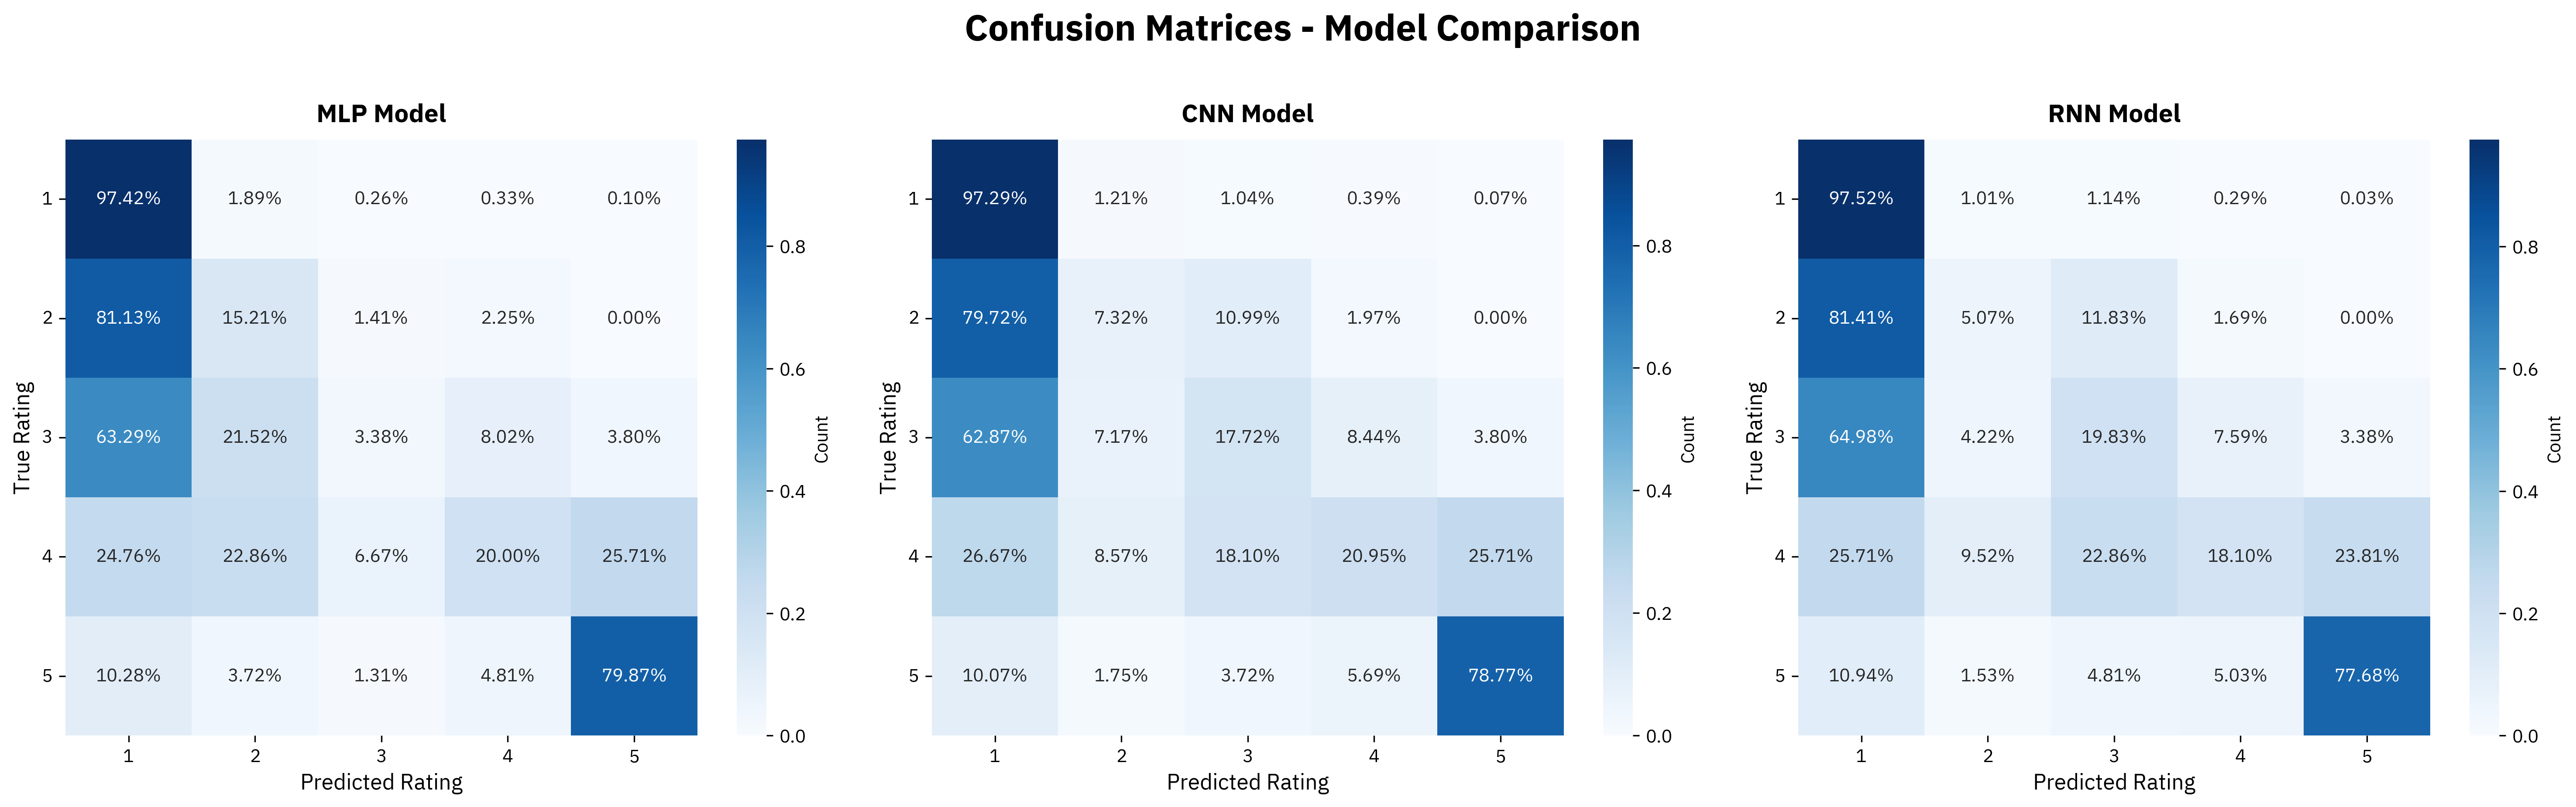

: 

: 

In [ ]:
# Create a 1x3 subplot for all model confusion matrices
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_confusion_matrices(all_models_results, y_test):
    """
    Create a single figure with 3 confusion matrices side by side
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Model order for consistent display
    model_order = ['MLP', 'CNN', 'RNN']
    
    for idx, model_name in enumerate(model_order):
        ax = axes[idx]
        
        # Get predictions and use y_test as true labels
        y_pred = all_models_results[model_name]['predictions']
        y_true = y_test
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        normalized_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Create heatmap
        sns.heatmap(normalized_cm, annot=True, fmt='.2%', cmap='Blues', 
                    xticklabels=range(1, 6), yticklabels=range(1, 6),
                    cbar_kws={'label': 'Count'},
                    ax=ax)
        
        # Get accuracy and F1 score
        accuracy = all_models_results[model_name]['accuracy']
        macro_f1 = all_models_results[model_name]['macro_f1']
        
        # Set title with metrics
        ax.set_title(f'{model_name} Model', 
                    fontproperties=bold_font, fontsize=14, pad=10)
        ax.set_xlabel('Predicted Rating', fontsize=12)
        ax.set_ylabel('True Rating', fontsize=12)
        
        # Rotate y-axis labels
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    # Add overall title
    plt.suptitle('Confusion Matrices - Model Comparison', 
                fontsize=20, fontproperties=bold_font, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    # # Print summary statistics
    # print("📊 CONFUSION MATRIX SUMMARY")
    # print("=" * 60)
    # for model_name in model_order:
    #     y_true = all_models_results[model_name]['true_labels']
    #     y_pred = all_models_results[model_name]['predictions']
    #     cm = confusion_matrix(y_true, y_pred)
        
    #     print(f"\n{model_name} Model:")
    #     print(f"   Diagonal sum (correct predictions): {cm.diagonal().sum()}")
    #     print(f"   Total predictions: {cm.sum()}")
    #     print(f"   Accuracy: {all_models_results[model_name]['accuracy']:.4f}")
        
    #     # Calculate per-class accuracy
    #     per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
    #     print(f"   Per-class accuracy:")
    #     for i, acc in enumerate(per_class_accuracy, start=1):
    #         print(f"     Rating {i}: {acc:.4f}")

# Plot all confusion matrices
plot_all_confusion_matrices(all_models_results, y_test)

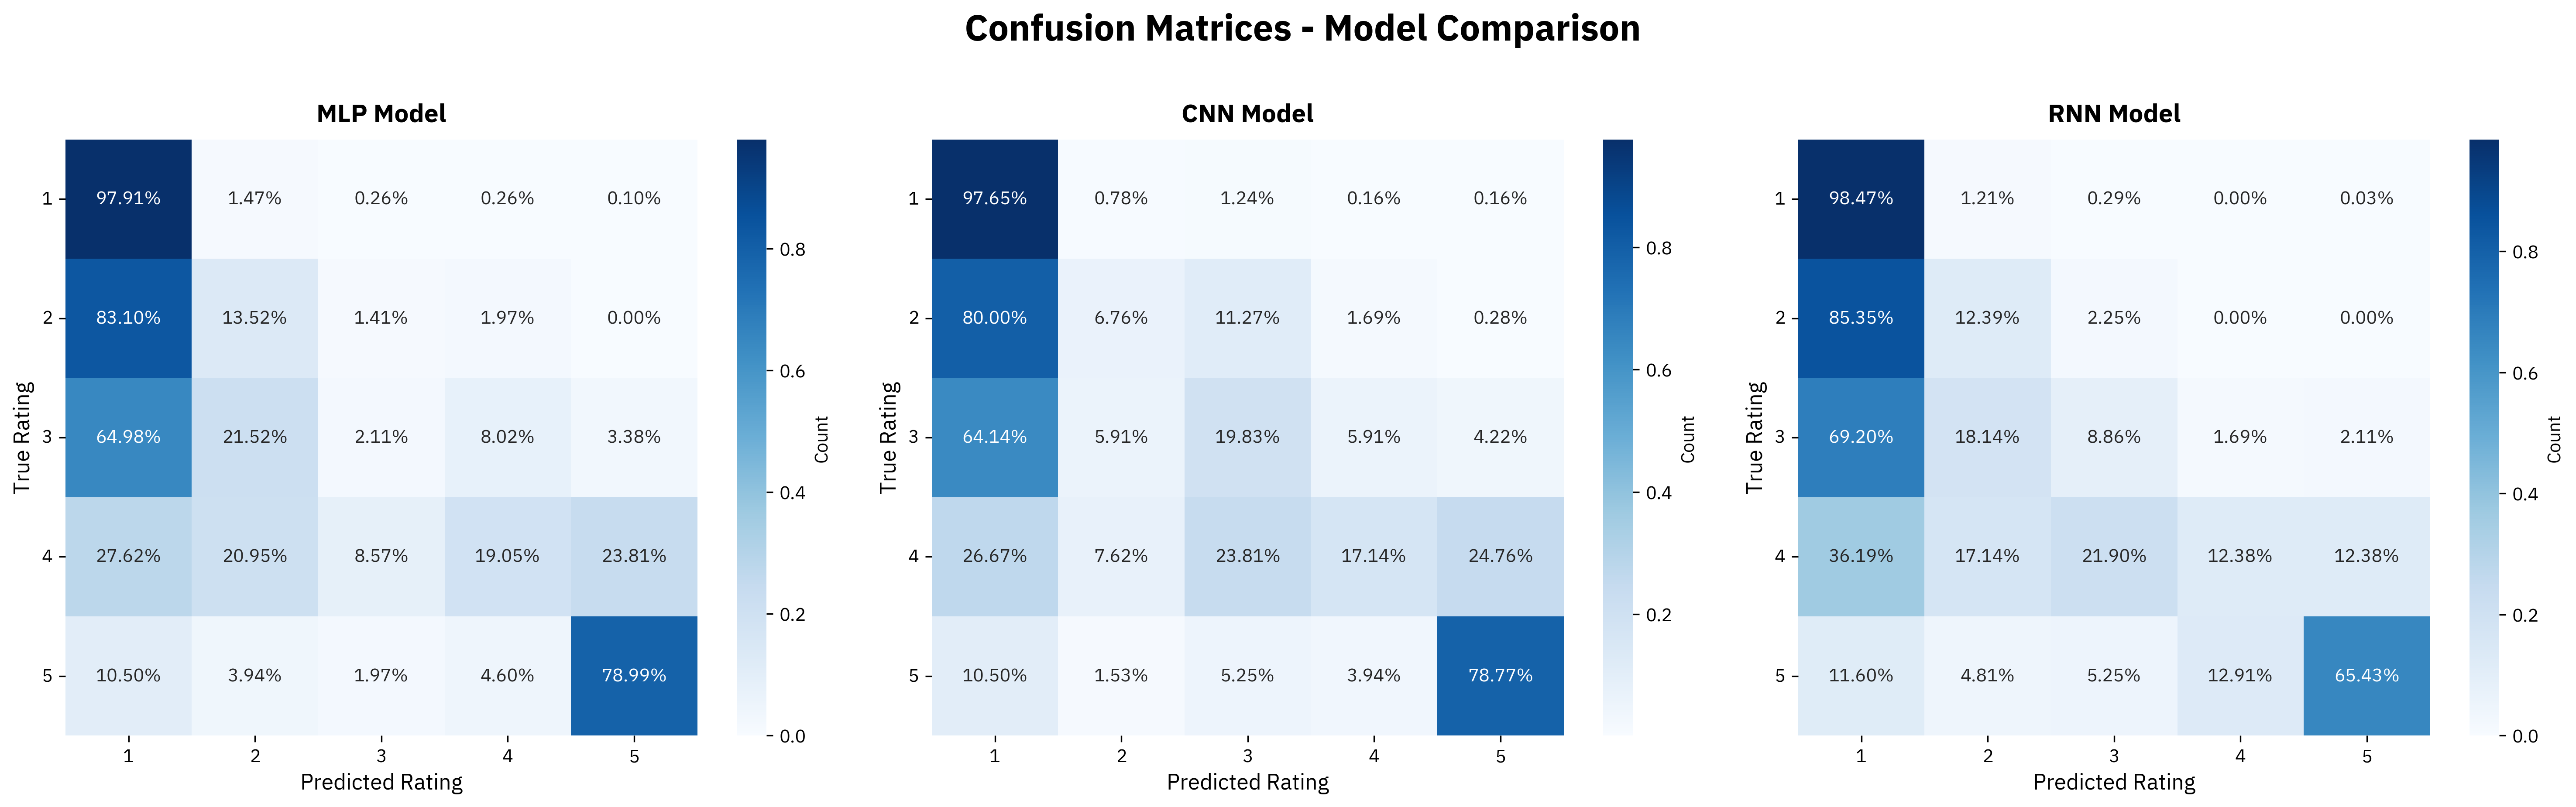

: 

: 

In [ ]:
# Create a 1x3 subplot for all model confusion matrices
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_confusion_matrices(all_models_results, y_test):
    """
    Create a single figure with 3 confusion matrices side by side
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Model order for consistent display
    model_order = ['MLP', 'CNN', 'RNN']
    
    for idx, model_name in enumerate(model_order):
        ax = axes[idx]
        
        # Get predictions and use y_test as true labels
        y_pred = all_models_results[model_name]['predictions']
        y_true = y_test
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        normalized_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Create heatmap
        sns.heatmap(normalized_cm, annot=True, fmt='.2%', cmap='Blues', 
                    xticklabels=range(1, 6), yticklabels=range(1, 6),
                    cbar_kws={'label': 'Count'},
                    ax=ax)
        
        # Get accuracy and F1 score
        accuracy = all_models_results[model_name]['accuracy']
        macro_f1 = all_models_results[model_name]['macro_f1']
        
        # Set title with metrics
        ax.set_title(f'{model_name} Model', 
                    fontproperties=bold_font, fontsize=14, pad=10)
        ax.set_xlabel('Predicted Rating', fontsize=12)
        ax.set_ylabel('True Rating', fontsize=12)
        
        # Rotate y-axis labels
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    # Add overall title
    plt.suptitle('Confusion Matrices - Model Comparison', 
                fontsize=20, fontproperties=bold_font, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    # # Print summary statistics
    # print("📊 CONFUSION MATRIX SUMMARY")
    # print("=" * 60)
    # for model_name in model_order:
    #     y_true = all_models_results[model_name]['true_labels']
    #     y_pred = all_models_results[model_name]['predictions']
    #     cm = confusion_matrix(y_true, y_pred)
        
    #     print(f"\n{model_name} Model:")
    #     print(f"   Diagonal sum (correct predictions): {cm.diagonal().sum()}")
    #     print(f"   Total predictions: {cm.sum()}")
    #     print(f"   Accuracy: {all_models_results[model_name]['accuracy']:.4f}")
        
    #     # Calculate per-class accuracy
    #     per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
    #     print(f"   Per-class accuracy:")
    #     for i, acc in enumerate(per_class_accuracy, start=1):
    #         print(f"     Rating {i}: {acc:.4f}")

# Plot all confusion matrices
plot_all_confusion_matrices(all_models_results, y_test)

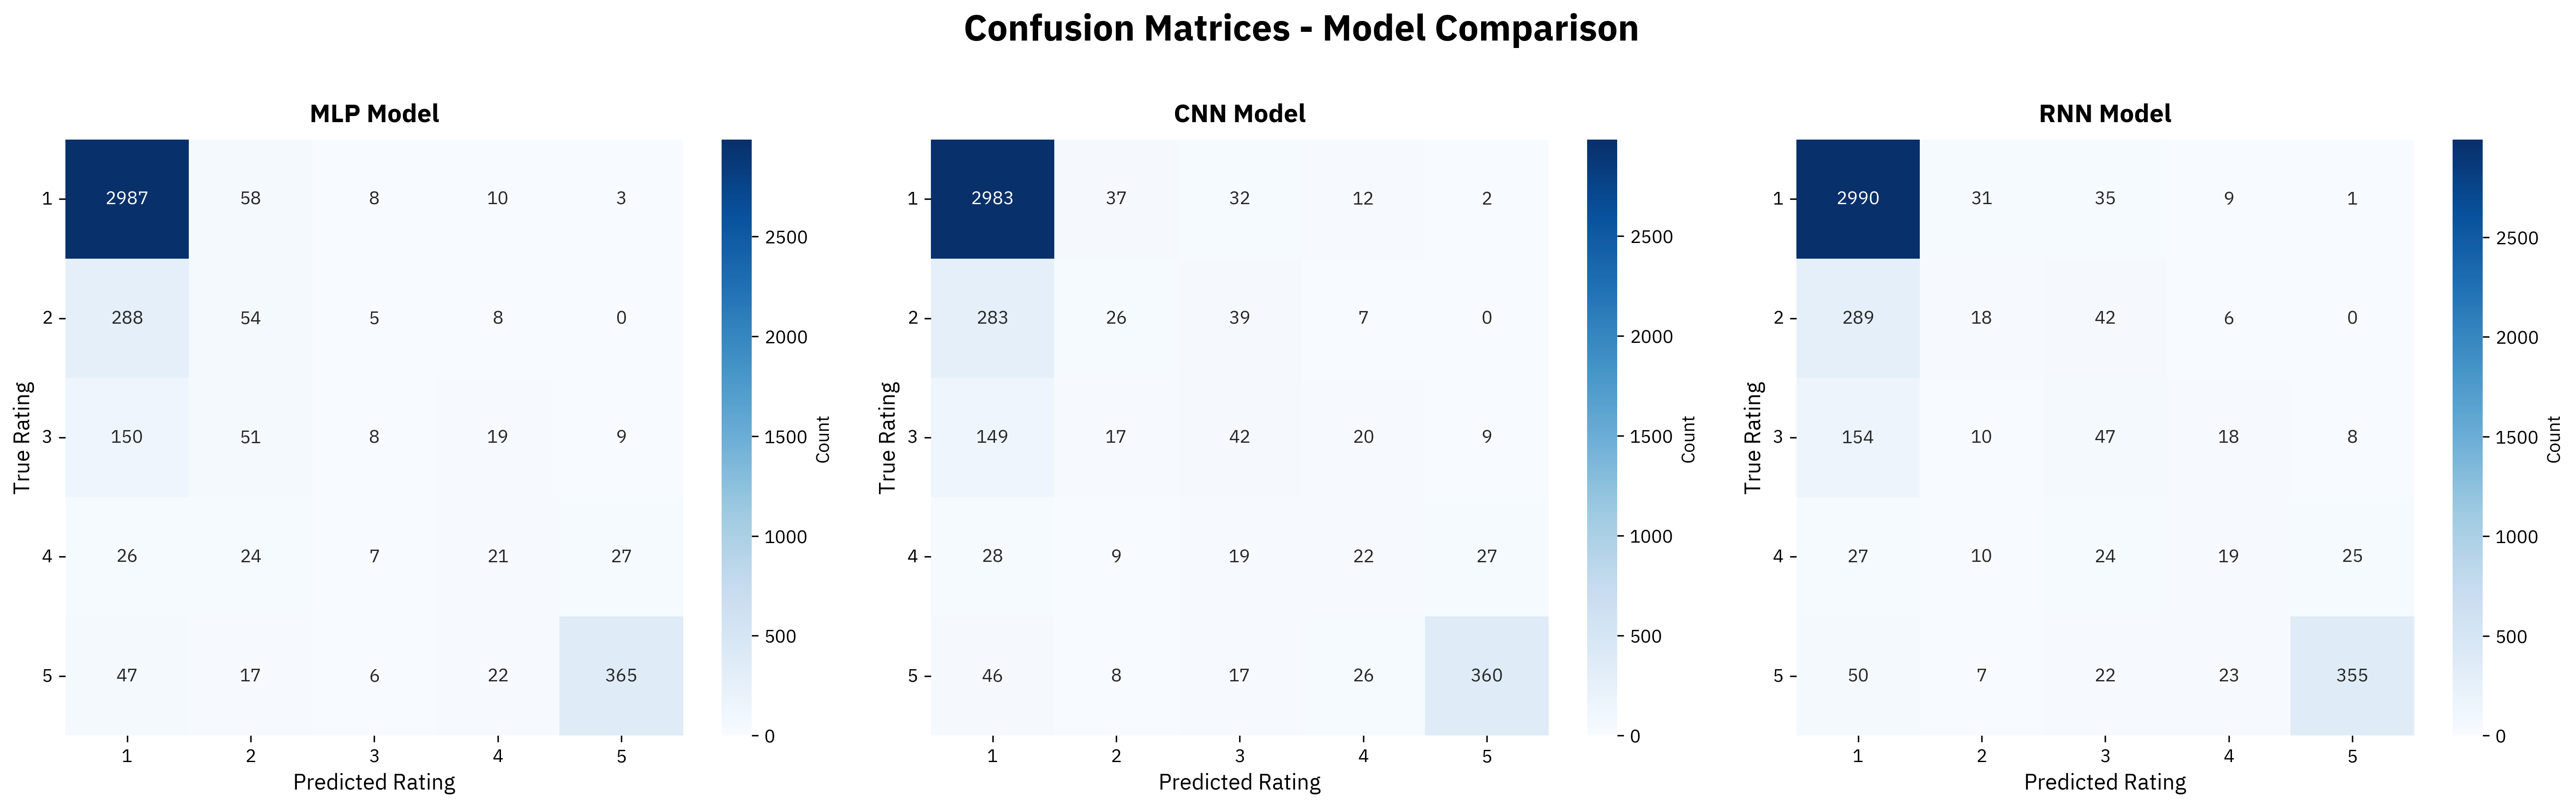

: 

: 

In [ ]:
# Create a 1x3 subplot for all model confusion matrices
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_confusion_matrices(all_models_results, y_test):
    """
    Create a single figure with 3 confusion matrices side by side
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Model order for consistent display
    model_order = ['MLP', 'CNN', 'RNN']
    
    for idx, model_name in enumerate(model_order):
        ax = axes[idx]
        
        # Get predictions and use y_test as true labels
        y_pred = all_models_results[model_name]['predictions']
        y_true = y_test
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        normalized_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Create heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=range(1, 6), yticklabels=range(1, 6),
                    cbar_kws={'label': 'Count'},
                    ax=ax)
        
        # Get accuracy and F1 score
        accuracy = all_models_results[model_name]['accuracy']
        macro_f1 = all_models_results[model_name]['macro_f1']
        
        # Set title with metrics
        ax.set_title(f'{model_name} Model', 
                    fontproperties=bold_font, fontsize=14, pad=10)
        ax.set_xlabel('Predicted Rating', fontsize=12)
        ax.set_ylabel('True Rating', fontsize=12)
        
        # Rotate y-axis labels
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    # Add overall title
    plt.suptitle('Confusion Matrices - Model Comparison', 
                fontsize=20, fontproperties=bold_font, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    # # Print summary statistics
    # print("📊 CONFUSION MATRIX SUMMARY")
    # print("=" * 60)
    # for model_name in model_order:
    #     y_true = all_models_results[model_name]['true_labels']
    #     y_pred = all_models_results[model_name]['predictions']
    #     cm = confusion_matrix(y_true, y_pred)
        
    #     print(f"\n{model_name} Model:")
    #     print(f"   Diagonal sum (correct predictions): {cm.diagonal().sum()}")
    #     print(f"   Total predictions: {cm.sum()}")
    #     print(f"   Accuracy: {all_models_results[model_name]['accuracy']:.4f}")
        
    #     # Calculate per-class accuracy
    #     per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
    #     print(f"   Per-class accuracy:")
    #     for i, acc in enumerate(per_class_accuracy, start=1):
    #         print(f"     Rating {i}: {acc:.4f}")

# Plot all confusion matrices
plot_all_confusion_matrices(all_models_results, y_test)

# Permutation Importance Analysis for All Models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

print("🔍 CALCULATING PERMUTATION IMPORTANCE FOR ALL MODELS")
print("=" * 70)

# Wrapper function for Keras models to work with sklearn's permutation_importance
def keras_predict_wrapper(model):
    """Wrapper to make Keras model compatible with permutation_importance"""
    def predict(X):
        # Get ordinal predictions and decode them
        probs = model.predict(X, verbose=0)
        # Decode to 1-5 ratings
        predictions = (np.sum(probs > 0.5, axis=1) + 1).astype(int)
        return np.clip(predictions, 1, 5)
    return predict

# Store permutation importance results
perm_importance_results = {}

# Calculate permutation importance for each model
models_dict = {
    'RNN': lstm_model
}

for model_name, model in models_dict.items():
    print(f"\n{'='*60}")
    print(f"Computing permutation importance for {model_name}...")
    print(f"{'='*60}")
    
    # Create wrapper function for this model
    predict_fn = keras_predict_wrapper(model)
    
    # Calculate permutation importance
    # Using a subset of test data for faster computation
    n_samples = min(1000, len(X_test_processed))
    X_subset = X_test_processed[:n_samples]
    y_subset = y_test.values[:n_samples]
    
    # Create a simple wrapper class
    class ModelWrapper:
        def __init__(self, predict_fn):
            self.predict_fn = predict_fn
        
        def predict(self, X):
            return self.predict_fn(X)
        
        def fit(self, X, y):
            return self
    
    wrapped_model = ModelWrapper(predict_fn)
    
    perm_importance = permutation_importance(
        estimator=wrapped_model,
        X=X_subset,
        y=y_subset,
        n_repeats=20,
        random_state=156,
        scoring='f1_macro',
        n_jobs=-1
    )
    
    # Store results
    perm_importance_results[model_name] = {
        'importances_mean': perm_importance.importances_mean,
        'importances_std': perm_importance.importances_std,
        'importances': perm_importance.importances
    }
    
    print(f"✅ {model_name} permutation importance calculated")
    print(f"   Feature importance ranking:")
    # Get feature names
    feature_names = X.columns.tolist()
    sorted_idx = perm_importance.importances_mean.argsort()[::-1]
    for idx in sorted_idx:
        print(f"     {feature_names[idx]}: {perm_importance.importances_mean[idx]:.4f} ± {perm_importance.importances_std[idx]:.4f}")

# Create visualization: 1x3 subplots for permutation importance
print(f"\n{'='*70}")
print("📊 CREATING PERMUTATION IMPORTANCE VISUALIZATIONS")
print(f"{'='*70}")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
feature_names = X.columns.tolist()

for idx, (model_name, results) in enumerate(perm_importance_results.items()):
    ax = axes[idx]
    
    # Sort features by importance
    sorted_idx = results['importances_mean'].argsort()
    
    # Create horizontal bar plot
    y_pos = np.arange(len(feature_names))
    ax.barh(y_pos, results['importances_mean'][sorted_idx], 
            xerr=results['importances_std'][sorted_idx],
            alpha=0.7, color='steelblue', edgecolor='black')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=10)
    ax.set_xlabel('Permutation Importance', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name} Model\nFeature Importance', 
                fontsize=13, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # # Add accuracy to title
    # accuracy = all_models_results[model_name]['accuracy']
    # ax.text(0.95, 0.95, f'Accuracy: {accuracy:.4f}', 
    #        transform=ax.transAxes, ha='right', va='top',
    #        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
    #        fontsize=10, fontweight='bold')

plt.suptitle('Permutation Feature Importance Comparison', 
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print comparative analysis
print(f"\n{'='*70}")
print("🎯 COMPARATIVE FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*70}")

# Create a summary dataframe
importance_summary = pd.DataFrame({
    'Feature': feature_names,
    # 'MLP_Importance': perm_importance_results['MLP']['importances_mean'],
    # 'CNN_Importance': perm_importance_results['CNN']['importances_mean'],
    'RNN_Importance': perm_importance_results['RNN']['importances_mean']
})

# Calculate average importance across models
importance_summary['Average_Importance'] = importance_summary[['RNN_Importance']].mean(axis=1)

# Sort by average importance
importance_summary = importance_summary.sort_values('Average_Importance', ascending=False)

print("\n📋 Overall Feature Importance Ranking (averaged across all models):")
print(importance_summary.to_string(index=False, float_format='%.4f'))

# Identify most important features
top_features = importance_summary.head(3)['Feature'].tolist()
print(f"\n🌟 TOP 3 MOST IMPORTANT FEATURES:")
for i, feature in enumerate(top_features, 1):
    avg_imp = importance_summary[importance_summary['Feature'] == feature]['Average_Importance'].values[0]
    print(f"   {i}. {feature}: {avg_imp:.4f}")

print(f"\n💡 INTERPRETATION:")
print("   - Higher values indicate features that significantly impact predictions")
print("   - Features are ranked by their contribution to model accuracy")
print("   - Consistency across models suggests robust feature importance")

# Check consistency across models
print(f"\n🔄 FEATURE IMPORTANCE CONSISTENCY CHECK:")
for feature in feature_names:
    lstm_imp = importance_summary[importance_summary['Feature'] == feature]['RNN_Importance'].values[0]
    
    std_dev = np.std([lstm_imp])
    consistency = "✅ Consistent" if std_dev < 0.01 else "⚠️ Varies across models"
    
    print(f"   {feature}: {consistency} (σ={std_dev:.4f})")

print(f"\n✅ Permutation importance analysis completed!")

🔍 CALCULATING PERMUTATION IMPORTANCE FOR ALL MODELS

Computing permutation importance for MLP...


/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/saving

✅ MLP permutation importance calculated
   Feature importance ranking:
     weighted_convenience: 0.2536 ± 0.0076
     customer_support_missing: 0.1375 ± 0.0068
     weighted_customer_support: 0.0978 ± 0.0078
     convenience_missing: 0.0950 ± 0.0053
     security_missing: 0.0862 ± 0.0070
     accessibility_missing: 0.0586 ± 0.0053
     weighted_security: 0.0567 ± 0.0059
     weighted_accessibility: 0.0173 ± 0.0044

Computing permutation importance for CNN...


/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 20 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 20 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 20 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/sav

✅ CNN permutation importance calculated
   Feature importance ranking:
     weighted_convenience: 0.1760 ± 0.0079
     convenience_missing: 0.0349 ± 0.0060
     weighted_customer_support: 0.0174 ± 0.0030
     accessibility_missing: 0.0085 ± 0.0036
     weighted_accessibility: 0.0077 ± 0.0027
     security_missing: 0.0073 ± 0.0049
     weighted_security: 0.0072 ± 0.0033
     customer_support_missing: 0.0011 ± 0.0036

Computing permutation importance for RNN...


/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/mochi/miniconda3/envs/guilherme/lib/python3.11/site-packages/keras/src/saving/sav

✅ RNN permutation importance calculated
   Feature importance ranking:
     weighted_convenience: 0.1810 ± 0.0065
     security_missing: 0.1467 ± 0.0081
     customer_support_missing: 0.1273 ± 0.0071
     accessibility_missing: 0.1160 ± 0.0088
     weighted_security: 0.1099 ± 0.0083
     weighted_customer_support: 0.0943 ± 0.0088
     convenience_missing: 0.0779 ± 0.0066
     weighted_accessibility: 0.0648 ± 0.0059

📊 CREATING PERMUTATION IMPORTANCE VISUALIZATIONS


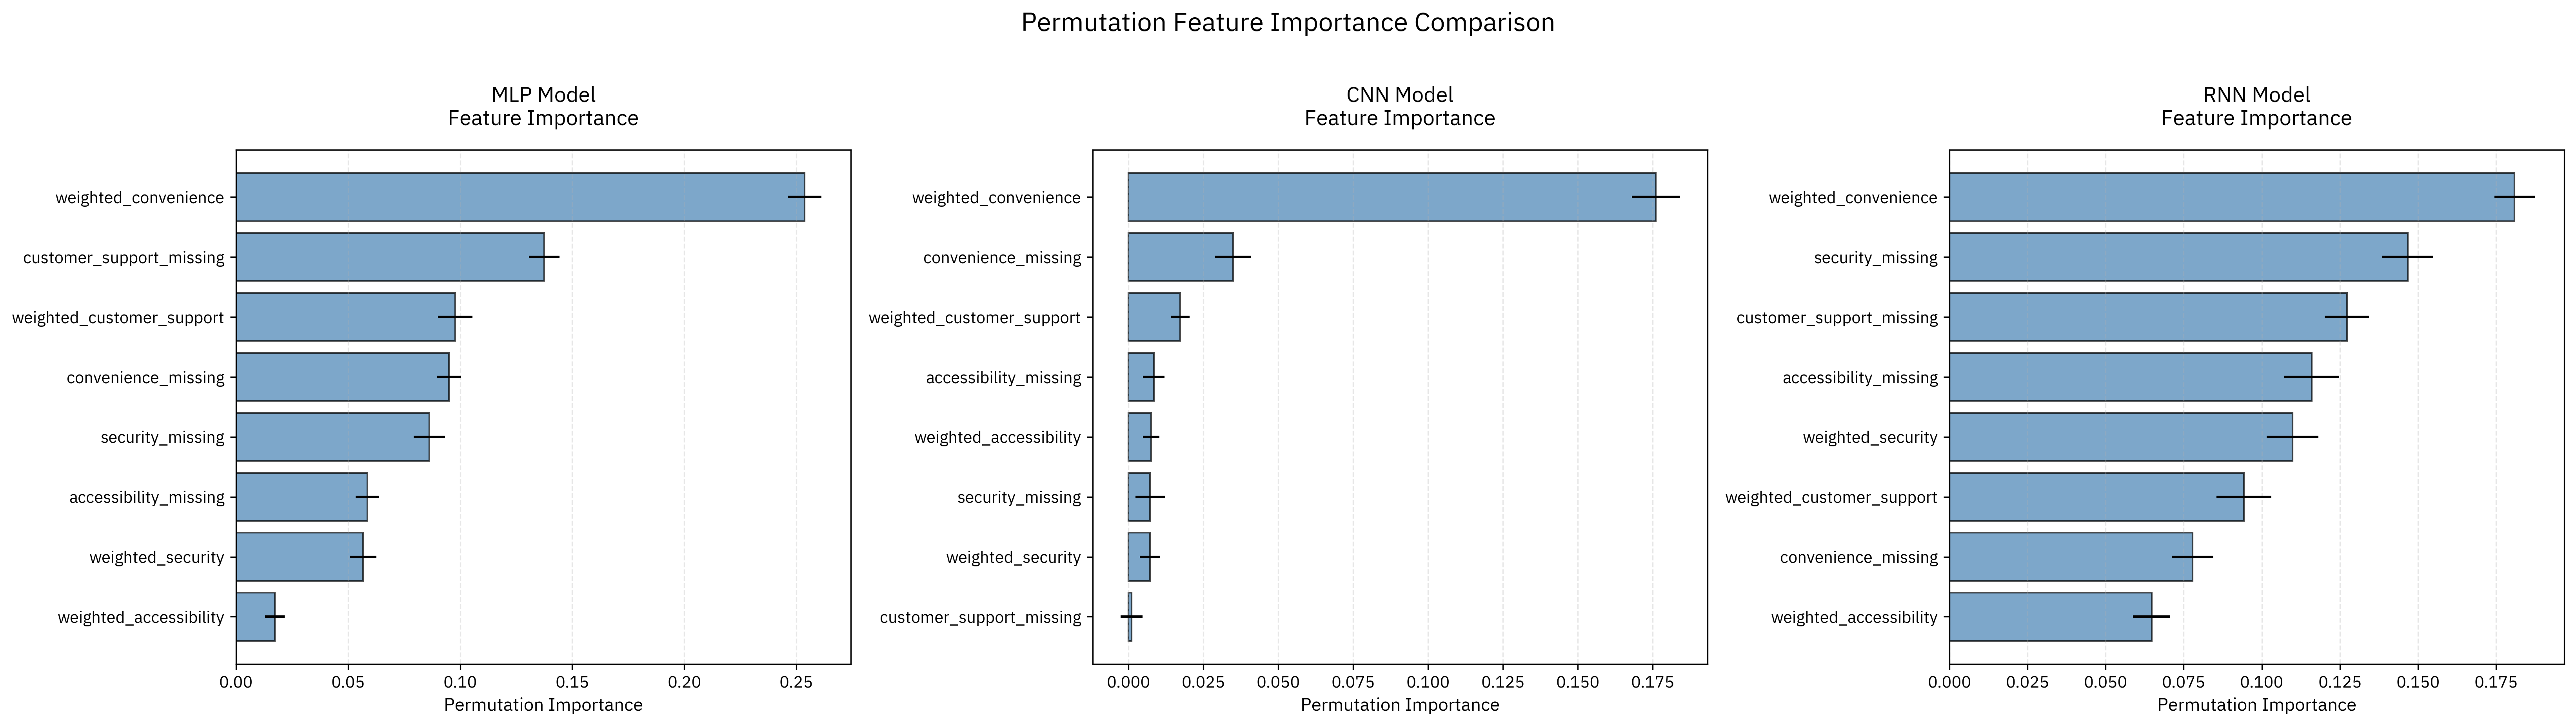


🎯 COMPARATIVE FEATURE IMPORTANCE ANALYSIS

📋 Overall Feature Importance Ranking (averaged across all models):
                  Feature  MLP_Importance  CNN_Importance  RNN_Importance  Average_Importance
     weighted_convenience          0.2536          0.1760          0.1810              0.2035
 customer_support_missing          0.1375          0.0011          0.1273              0.0886
         security_missing          0.0862          0.0073          0.1467              0.0801
weighted_customer_support          0.0978          0.0174          0.0943              0.0698
      convenience_missing          0.0950          0.0349          0.0779              0.0693
    accessibility_missing          0.0586          0.0085          0.1160              0.0610
        weighted_security          0.0567          0.0072          0.1099              0.0579
   weighted_accessibility          0.0173          0.0077          0.0648              0.0299

🌟 TOP 3 MOST IMPORTANT FEATURES:
   1. wei

: 

: 

: 

In [ ]:
# Permutation Importance Analysis for All Models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

print("🔍 CALCULATING PERMUTATION IMPORTANCE FOR ALL MODELS")
print("=" * 70)

# Wrapper function for Keras models to work with sklearn's permutation_importance
def keras_predict_wrapper(model):
    """Wrapper to make Keras model compatible with permutation_importance"""
    def predict(X):
        # Get ordinal predictions and decode them
        probs = model.predict(X, verbose=0)
        # Decode to 1-5 ratings
        predictions = (np.sum(probs > 0.5, axis=1) + 1).astype(int)
        return np.clip(predictions, 1, 5)
    return predict

# Store permutation importance results
perm_importance_results = {}

# Calculate permutation importance for each model
models_dict = {
    'RNN': lstm_model
}

for model_name, model in models_dict.items():
    print(f"\n{'='*60}")
    print(f"Computing permutation importance for {model_name}...")
    print(f"{'='*60}")
    
    # Create wrapper function for this model
    predict_fn = keras_predict_wrapper(model)
    
    # Calculate permutation importance
    # Using a subset of test data for faster computation
    n_samples = min(1000, len(X_test_processed))
    X_subset = X_test_processed[:n_samples]
    y_subset = y_test.values[:n_samples]
    
    # Create a simple wrapper class
    class ModelWrapper:
        def __init__(self, predict_fn):
            self.predict_fn = predict_fn
        
        def predict(self, X):
            return self.predict_fn(X)
        
        def fit(self, X, y):
            return self
    
    wrapped_model = ModelWrapper(predict_fn)
    
    perm_importance = permutation_importance(
        estimator=wrapped_model,
        X=X_subset,
        y=y_subset,
        n_repeats=20,
        random_state=156,
        scoring='accuracy',
        n_jobs=-1
    )
    
    # Store results
    perm_importance_results[model_name] = {
        'importances_mean': perm_importance.importances_mean,
        'importances_std': perm_importance.importances_std,
        'importances': perm_importance.importances
    }
    
    print(f"✅ {model_name} permutation importance calculated")
    print(f"   Feature importance ranking:")
    # Get feature names
    feature_names = X.columns.tolist()
    sorted_idx = perm_importance.importances_mean.argsort()[::-1]
    for idx in sorted_idx:
        print(f"     {feature_names[idx]}: {perm_importance.importances_mean[idx]:.4f} ± {perm_importance.importances_std[idx]:.4f}")

# Create visualization: 1x3 subplots for permutation importance
print(f"\n{'='*70}")
print("📊 CREATING PERMUTATION IMPORTANCE VISUALIZATIONS")
print(f"{'='*70}")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
feature_names = X.columns.tolist()

for idx, (model_name, results) in enumerate(perm_importance_results.items()):
    ax = axes[idx]
    
    # Sort features by importance
    sorted_idx = results['importances_mean'].argsort()
    
    # Create horizontal bar plot
    y_pos = np.arange(len(feature_names))
    ax.barh(y_pos, results['importances_mean'][sorted_idx], 
            xerr=results['importances_std'][sorted_idx],
            alpha=0.7, color='steelblue', edgecolor='black')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=10)
    ax.set_xlabel('Permutation Importance', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name} Model\nFeature Importance', 
                fontsize=13, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # # Add accuracy to title
    # accuracy = all_models_results[model_name]['accuracy']
    # ax.text(0.95, 0.95, f'Accuracy: {accuracy:.4f}', 
    #        transform=ax.transAxes, ha='right', va='top',
    #        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
    #        fontsize=10, fontweight='bold')

plt.suptitle('Permutation Feature Importance Comparison', 
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print comparative analysis
print(f"\n{'='*70}")
print("🎯 COMPARATIVE FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*70}")

# Create a summary dataframe
importance_summary = pd.DataFrame({
    'Feature': feature_names,
    'RNN_Importance': perm_importance_results['RNN']['importances_mean']
})

# Calculate average importance across models
importance_summary['Average_Importance'] = importance_summary[[ 'RNN_Importance']].mean(axis=1)

# Sort by average importance
importance_summary = importance_summary.sort_values('Average_Importance', ascending=False)

print("\n📋 Overall Feature Importance Ranking (averaged across all models):")
print(importance_summary.to_string(index=False, float_format='%.4f'))

# Identify most important features
top_features = importance_summary.head(3)['Feature'].tolist()
print(f"\n🌟 TOP 3 MOST IMPORTANT FEATURES:")
for i, feature in enumerate(top_features, 1):
    avg_imp = importance_summary[importance_summary['Feature'] == feature]['Average_Importance'].values[0]
    print(f"   {i}. {feature}: {avg_imp:.4f}")

print(f"\n💡 INTERPRETATION:")
print("   - Higher values indicate features that significantly impact predictions")
print("   - Features are ranked by their contribution to model accuracy")
print("   - Consistency across models suggests robust feature importance")

# Check consistency across models
print(f"\n🔄 FEATURE IMPORTANCE CONSISTENCY CHECK:")
for feature in feature_names:
    mlp_imp = importance_summary[importance_summary['Feature'] == feature]['MLP_Importance'].values[0]
    cnn_imp = importance_summary[importance_summary['Feature'] == feature]['CNN_Importance'].values[0]
    lstm_imp = importance_summary[importance_summary['Feature'] == feature]['RNN_Importance'].values[0]
    
    std_dev = np.std([mlp_imp, cnn_imp, lstm_imp])
    consistency = "✅ Consistent" if std_dev < 0.01 else "⚠️ Varies across models"
    
    print(f"   {feature}: {consistency} (σ={std_dev:.4f})")

print(f"\n✅ Permutation importance analysis completed!")

: 

: 